# Pipeline Lengkap: Forecasting Restock Obat
## Klinik Del — Institut Teknologi Del

**Pendekatan:** SES · Croston · SBA + Volume Kunjungan Scaler (E2)  
**Kebijakan Stok:** Min-Max + Safety Stock (Z=1.65, service level 95%)  
**Klasifikasi Demand:** Kuadran ADI/CV² (Syntetos et al. 2005)

```
Data Mentah → X_t → Klasifikasi ADI/CV²
→ SES / Croston / SBA → E2 Scaler → Evaluasi → Kebijakan Stok → Model pkl
```

## 0. Setup Library & Konfigurasi

In [28]:
import warnings; warnings.filterwarnings('ignore')
import sys, os, math, json, pickle
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats.mstats import winsorize as scipy_winsorize
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

plt.rcParams.update({'figure.dpi':120,'font.family':'DejaVu Sans',
                     'axes.titlesize':12,'axes.labelsize':10})
pd.set_option('display.max_columns',30)
pd.set_option('display.max_rows',100)
pd.set_option('display.width',180)
pd.set_option('display.float_format','{:.2f}'.format)

BASE          = '..'
RAW_EXCEL     = os.path.join(BASE,'Rekap_2025_Gabungan_Terisi.xlsx')
PANEL_PARQUET = os.path.join(BASE,'data','panel_bulanan.parquet')
PKL_OUT       = os.path.join(BASE,'models','restock_pipeline_model_final.pkl')
OUT_DIR       = os.path.join(BASE,'output_analisis')
os.makedirs(OUT_DIR, exist_ok=True)

ADI_CUT, CV2_CUT = 1.32, 0.49
TRAIN_M = list(range(1,11))
VAL_M   = [7,8,9,10]
TEST_M  = [11,12]
LT, R, Z = 1.0, 1.0, 1.65

print('Setup selesai.')

Setup selesai.


## 1. Load & Kenali Data Mentah

| Kolom | Keterangan |
|---|---|
| `Tanggal Masuk` | Tanggal kunjungan |
| `Register` | ID unik kunjungan |
| `Resep Obat` | Nama obat |
| `JUMLAH` | Jumlah pemakaian (unit) |
| `SISA_STOK` | Stok akhir |
| `Kode Diagnosa` | ICD-10 (untuk VEN) |

In [29]:
raw = pd.read_excel(RAW_EXCEL, sheet_name='Rekap Kunjungan')
raw['bulan'] = pd.to_datetime(raw['Tanggal Masuk'], errors='coerce').dt.month

print(f'Shape   : {raw.shape}')
print(f'Bulan   : {int(raw.bulan.min())}–{int(raw.bulan.max())}')
print(f'Obat    : {raw["Resep Obat"].nunique()}')
print(f'Register: {raw["Register"].nunique():,}')

print('\n--- 5 baris pertama ---')
display(raw.head())

print('\n--- Statistik kolom numerik ---')
display(raw.describe().T.round(1))

print('\n--- Kunjungan unik per bulan ---')
visit_bln = raw.groupby('bulan')['Register'].nunique()
display(visit_bln.rename('kunjungan_unik').to_frame())

Shape   : (21079, 9)
Bulan   : 1–12
Obat    : 250
Register: 5,397

--- 5 baris pertama ---


,Tanggal Masuk,Register,Kode Diagnosa,Diagnosa Primer,Resep Obat,JUMLAH,SISA_STOK,SATUAN,bulan
0,2025-01-06,1665,J06.9,"Acute upper respiratory infection, unspecified",AMBROXOL SIRUP,NaN,NaN,NaN,1
1,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",ACETYLCYSTEIN KAP,471.00,3953.00,KAPSUL,1
2,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",BECEFORT TAB,380.00,925.00,TABLET,1
3,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",NEO-PROTIFED (TRIPROLIDIN + PSEUDOEFEDRIN) TAB,1194.00,2644.00,TABLET,1
4,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",PAMOL TAB 500MG (PARACETAMOL TAB),NaN,NaN,NaN,1



--- Statistik kolom numerik ---


,count,mean,min,25%,50%,75%,max,std
Tanggal Masuk,21079,2025-07-14 08:40:37.459082752,2025-01-06 00:00:00,2025-04-21 00:00:00,2025-08-15 00:00:00,2025-10-07 00:00:00,2025-12-19 00:00:00,NaN
Register,21079.00,4655.27,1665.00,3332.50,4793.00,5986.00,7618.00,1600.10
JUMLAH,13406.00,554.42,0.00,70.00,380.00,770.00,2900.00,658.64
SISA_STOK,12662.00,972.64,0.00,211.00,678.00,1630.00,3953.00,922.28
bulan,21079.00,6.96,1.00,4.00,8.00,10.00,12.00,3.27



--- Kunjungan unik per bulan ---


,kunjungan_unik
bulan,
1,346
2,541
3,521
4,417
5,389
6,274
7,351
8,450
9,646


## 2. Pembentukan Target X_t — Pemakaian Bulanan per Obat

$X_t$ = total unit pemakaian per obat per bulan. Data long → pivot → matriks obat×12 bulan.

- **no_demand** (tidak diresepkan) → **0**
- **data_gap** (diresepkan tapi JUMLAH NaN) → tetap **NaN**

In [30]:
obs = (raw.dropna(subset=['Resep Obat','JUMLAH'])
       .groupby(['Resep Obat','bulan'])['JUMLAH'].first().reset_index())
obs.columns = ['obat','bulan','X_t']
X = obs.pivot(index='obat',columns='bulan',values='X_t').reindex(columns=range(1,13))

print(f'Matriks X_t: {X.shape[0]} obat x 12 bulan')
print(f'Sel ber-nilai : {int(X.notna().sum().sum())} ({X.notna().sum().sum()/X.size*100:.1f}%)')

print('\n--- Matriks X_t (10 obat pertama, unit/bulan) ---')
display(X.head(10).style.background_gradient(cmap='Blues',axis=None).format('{:.0f}',na_rep='-'))

Matriks X_t: 175 obat x 12 bulan
Sel ber-nilai : 899 (42.8%)

--- Matriks X_t (10 obat pertama, unit/bulan) ---


bulan,1,2,3,4,5,6,7,8,9,10,11,12
obat,,,,,,,,,,,,
ACETYLCYSTEIN KAP,471,749,570,396,419,290,475,850,790,1368,869,307
ACITRAL TAB,-,70,-,-,-,-,-,-,-,-,-,-
ACYCLOVIR SALEP,13,23,22,-,25,20,14,-,1,50,-,20
ACYCLOVIR TABLET,240,0,740,-,390,160,236,-,234,316,-,400
ALLOPURINOL TABLET,10,-,18,-,-,-,40,10,-,47,30,10
AMBEVEN TABLET,-,30,10,-,40,-,-,60,60,40,30,30
AMBROXOL SIRUP,-,3,-,-,-,-,-,-,-,-,-,-
AMBROXOL TABLET,-,0,-,-,-,-,0,0,110,700,-,-
AMLODIPINE 10 MG TABLET,30,76,68,90,20,10,35,30,70,42,48,30


In [31]:
presc = set(map(tuple,raw.dropna(subset=['Resep Obat'])[['Resep Obat','bulan']]
               .dropna().drop_duplicates().itertuples(index=False,name=None)))

X_clean = X.copy()
n_gap = n_nod = 0
for ob in X.index:
    for b in range(1,13):
        v = X.at[ob,b]
        if pd.isna(v):
            if (ob,b) in presc: n_gap += 1
            else: X_clean.at[ob,b] = 0.0; n_nod += 1

def winsor_row(s):
    v = s.dropna()
    if len(v)<4: return s
    q1,q3 = v.quantile(.25),v.quantile(.75); iqr=q3-q1
    return s.clip(lower=max(q1-1.5*iqr,0),upper=q3+1.5*iqr)

X_winsor = X_clean.apply(winsor_row,axis=1)

# Ringkasan per obat
summary_xt = pd.DataFrame({
    'n_bulan_ada_data' : X.notna().sum(axis=1),
    'n_bulan_zero'     : (X_clean==0).sum(axis=1),
    'n_data_gap'       : X.isna().sum(axis=1) - (X_clean==0).sum(axis=1),
    'total_pemakaian'  : X_clean.sum(axis=1).round(0),
    'AMC'              : X_clean.mean(axis=1).round(1),
    'max_bulan'        : X_clean.max(axis=1).round(0),
})
summary_xt['n_data_gap'] = summary_xt['n_data_gap'].clip(lower=0)

print(f'no_demand->0  : {n_nod} sel')
print(f'data_gap (NaN): {n_gap} sel')
print(f'Winsorize     : {int((X_winsor!=X_clean).sum().sum())} sel diubah')

print('\n--- Ringkasan pemakaian per obat (semua {len(summary_xt)} obat) ---')
display(summary_xt.sort_values('total_pemakaian',ascending=False))

no_demand->0  : 893 sel
data_gap (NaN): 308 sel
Winsorize     : 462 sel diubah

--- Ringkasan pemakaian per obat (semua {len(summary_xt)} obat) ---


,n_bulan_ada_data,n_bulan_zero,n_data_gap,total_pemakaian,AMC,max_bulan
obat,,,,,,
METHYLPREDNISOLONE 4 MG TABLET,12,1,0,9137.00,761.40,2900.00
ACETYLCYSTEIN KAP,12,0,0,7554.00,629.50,1368.00
BECOMZET TABLET,11,2,0,7542.00,628.50,2155.00
NEO-PROTIFED (TRIPROLIDIN + PSEUDOEFEDRIN) TAB,10,3,0,6658.00,554.80,1194.00
RANITIDINE TABLET,12,2,0,5265.00,438.80,980.00
...,...,...,...,...,...,...
Norages Injeksi,1,4,7,0.00,0.00,0.00
PARACETAMOL 500MG TABLET,2,12,0,0.00,0.00,0.00
RANIGEN (RANITIDIN) TABLET,1,10,1,0.00,0.00,0.00


## 3. Exploratory Data Analysis (EDA)

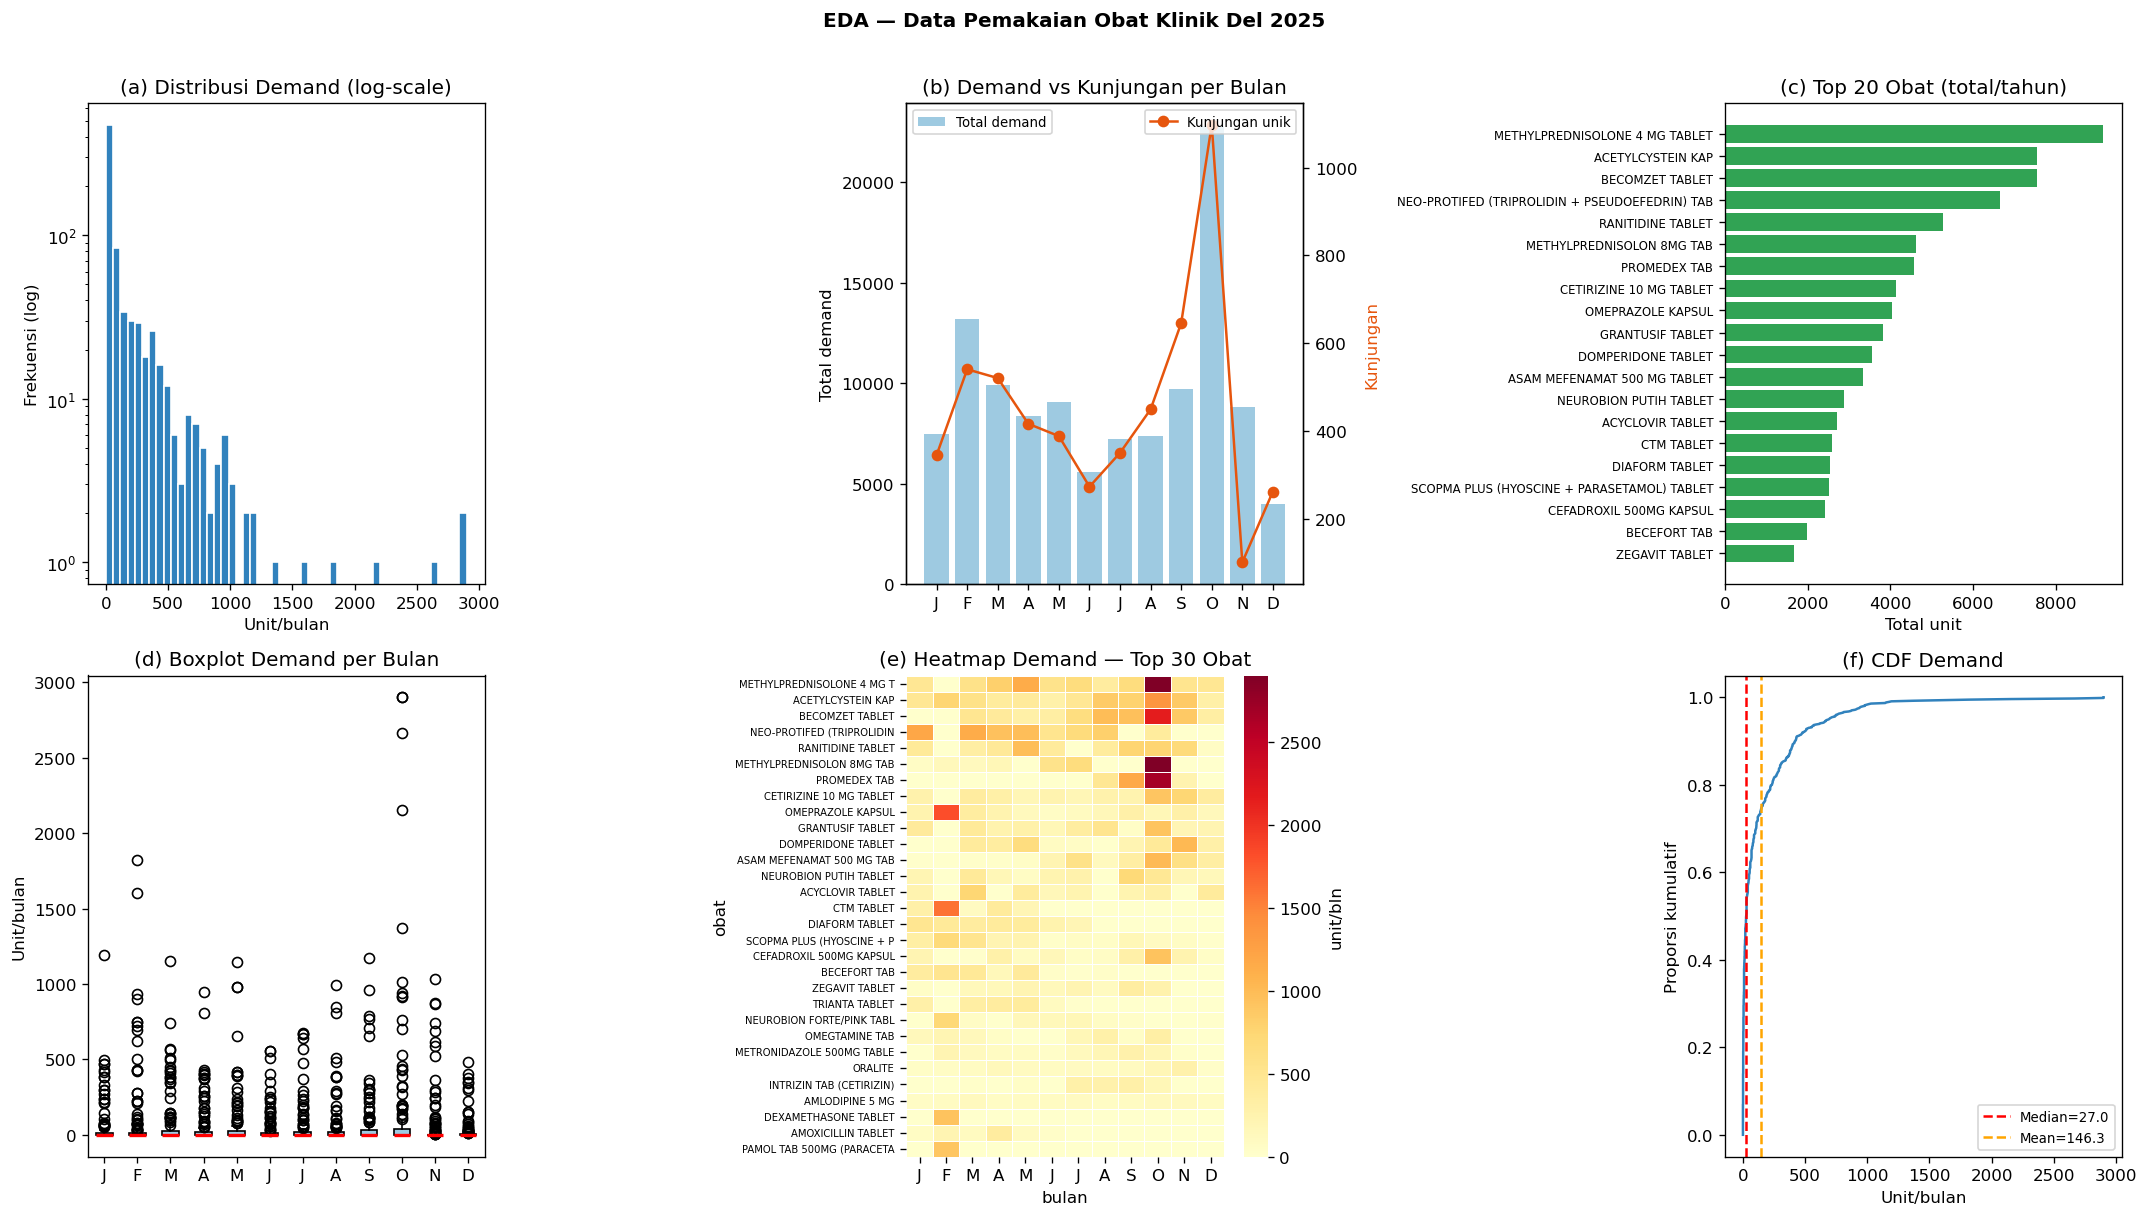

Pearson: Total Demand vs Kunjungan r=0.874 p=0.0002

--- Statistik demand agregat per bulan ---


,kunjungan,sum,mean,median,std
bulan,,,,,
1,346,7494.00,51.70,0.00,144.60
2,541,13182.00,75.30,0.00,243.10
3,521,9904.00,70.70,0.00,170.10
4,417,8351.00,56.40,0.00,141.30
5,389,9045.00,62.40,0.00,175.50
6,274,5594.00,37.50,0.00,99.40
7,351,7247.00,50.30,0.00,134.50
8,450,7377.00,50.90,0.00,151.90
9,646,9703.00,67.90,1.00,182.80


In [32]:
# --- Visualisasi 1: Overview EDA ---
fig, axes = plt.subplots(2,3,figsize=(18,10))

# (a) Distribusi demand log-scale
all_d = X_clean.values.flatten(); all_d = all_d[~np.isnan(all_d)&(all_d>0)]
axes[0,0].hist(all_d,bins=50,color='#3182bd',edgecolor='white',log=True)
axes[0,0].set_title('(a) Distribusi Demand (log-scale)')
axes[0,0].set_xlabel('Unit/bulan'); axes[0,0].set_ylabel('Frekuensi (log)')

# (b) Total demand vs kunjungan per bulan
tot_bln = X_clean.sum(axis=0)
ax2=axes[0,1].twinx()
axes[0,1].bar(range(1,13),tot_bln,color='#9ecae1',label='Total demand')
ax2.plot(range(1,13),visit_bln,'o-',color='#e6550d',label='Kunjungan unik')
axes[0,1].set_title('(b) Demand vs Kunjungan per Bulan')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[0,1].set_ylabel('Total demand'); ax2.set_ylabel('Kunjungan',color='#e6550d')
axes[0,1].legend(loc='upper left',fontsize=8); ax2.legend(loc='upper right',fontsize=8)

# (c) Top 20 obat
top20=X_clean.sum(axis=1).nlargest(20)
axes[0,2].barh(top20.index[::-1],top20.values[::-1],color='#31a354')
axes[0,2].set_title('(c) Top 20 Obat (total/tahun)')
axes[0,2].set_xlabel('Total unit'); axes[0,2].tick_params(axis='y',labelsize=7)

# (d) Boxplot demand per bulan
data_bx=[X_clean[b].dropna().values for b in range(1,13)]
axes[1,0].boxplot(data_bx,labels=['J','F','M','A','M','J','J','A','S','O','N','D'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#9ecae1'),medianprops=dict(color='red',lw=2))
axes[1,0].set_title('(d) Boxplot Demand per Bulan')
axes[1,0].set_ylabel('Unit/bulan')

# (e) Heatmap X_t top 30 obat
top30=X_clean.sum(axis=1).nlargest(30).index
sns.heatmap(X_clean.loc[top30].fillna(0),ax=axes[1,1],cmap='YlOrRd',
            linewidths=0.3,linecolor='white',
            xticklabels=['J','F','M','A','M','J','J','A','S','O','N','D'],
            yticklabels=[o[:25] for o in top30],cbar_kws={'label':'unit/bln'})
axes[1,1].set_title('(e) Heatmap Demand — Top 30 Obat')
axes[1,1].tick_params(axis='y',labelsize=6)

# (f) CDF pemakaian
sorted_d=np.sort(all_d)
axes[1,2].plot(sorted_d,np.linspace(0,1,len(sorted_d)),color='#3182bd')
axes[1,2].axvline(np.median(all_d),color='red',ls='--',label=f'Median={np.median(all_d):.1f}')
axes[1,2].axvline(np.mean(all_d),color='orange',ls='--',label=f'Mean={np.mean(all_d):.1f}')
axes[1,2].set_title('(f) CDF Demand'); axes[1,2].set_xlabel('Unit/bulan')
axes[1,2].set_ylabel('Proporsi kumulatif'); axes[1,2].legend(fontsize=8)

plt.suptitle('EDA — Data Pemakaian Obat Klinik Del 2025',fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'eda_overview.png'),dpi=150,bbox_inches='tight')
plt.show()

r_ev,p_ev=stats.pearsonr(visit_bln.reindex(range(1,13)).fillna(0),tot_bln.fillna(0))
print(f'Pearson: Total Demand vs Kunjungan r={r_ev:.3f} p={p_ev:.4f}')

print('\n--- Statistik demand agregat per bulan ---')
agg_bln = X_clean.agg(['sum','mean','median','std']).T.round(1)
agg_bln.index.name='bulan'
agg_bln.insert(0,'kunjungan',visit_bln.values)
display(agg_bln)

## 4. Klasifikasi Pola Permintaan — Kuadran ADI/CV²

| Kuadran | ADI | CV² | Kategori | Metode |
|---|---|---|---|---|
| I | <1.32 | <0.49 | Smooth | SES |
| II | <1.32 | ≥0.49 | Erratic | SES (α besar) |
| III | ≥1.32 | <0.49 | Intermittent | Croston/SBA |
| IV | ≥1.32 | ≥0.49 | Lumpy | Croston/SBA |

In [33]:
def klasifikasi(row):
    v=row.dropna(); nz=v[v>0]
    if len(nz)<2 or len(v)<4: return 'data tidak cukup',np.nan,np.nan
    adi=len(v)/len(nz)
    cv2=(nz.std()/nz.mean())**2 if nz.mean()>0 else np.nan
    if adi<ADI_CUT and cv2<CV2_CUT: c='smooth'
    elif adi<ADI_CUT: c='erratic'
    elif cv2<CV2_CUT: c='intermittent'
    else: c='lumpy'
    return c,adi,cv2

kat={}; ADI_map={}; CV2_map={}
for ob in X_clean.index:
    c,a,cv=klasifikasi(X_clean.loc[ob])
    kat[ob]=c; ADI_map[ob]=a; CV2_map[ob]=cv

kat=pd.Series(kat,name='kategori_demand')

# Tabel lengkap per obat
df_kat=pd.DataFrame({'ADI':ADI_map,'CV2':CV2_map,'kategori':kat}).round(3)
df_kat['AMC_bln']=X_clean.mean(axis=1).round(1)
df_kat['total_thn']=X_clean.sum(axis=1).round(0)
df_kat['n_zero_bln']=(X_clean==0).sum(axis=1)

print('--- Distribusi kategori ---')
print(kat.value_counts().to_string())

print('\n--- Tabel ADI/CV² per obat (diurutkan kategori lalu ADI) ---')
display(df_kat.sort_values(['kategori','ADI']).style
        .background_gradient(subset=['ADI'],cmap='Oranges')
        .background_gradient(subset=['CV2'],cmap='Blues')
        .background_gradient(subset=['total_thn'],cmap='Greens')
        .format({'ADI':'{:.3f}','CV2':'{:.3f}','AMC_bln':'{:.1f}','total_thn':'{:.0f}'}))

--- Distribusi kategori ---
kategori_demand
data tidak cukup    66
intermittent        48
lumpy               33
erratic             15
smooth              13

--- Tabel ADI/CV² per obat (diurutkan kategori lalu ADI) ---


,ADI,CV2,kategori,AMC_bln,total_thn,n_zero_bln
ACITRAL TAB,nan,nan,data tidak cukup,11.7,70,5
AMBROXOL SIRUP,nan,nan,data tidak cukup,3.0,3,0
ANTASIDA TABLET,nan,nan,data tidak cukup,20.4,245,11
ANTRAIN TAB (METAMIZOLE SODIUM),nan,nan,data tidak cukup,3.3,30,8
BEDAK SALISYL,nan,nan,data tidak cukup,0.1,1,6
BETADINE KUMUR,nan,nan,data tidak cukup,0.0,0,5
BIOLYSIN KIDS TAB KUNYAH,nan,nan,data tidak cukup,0.4,2,4
BIOPLACENTON,nan,nan,data tidak cukup,0.0,0,2
"BISOPROLOL 2,5MG",nan,nan,data tidak cukup,0.0,0,10
Betadine 15 ml,nan,nan,data tidak cukup,0.1,1,11


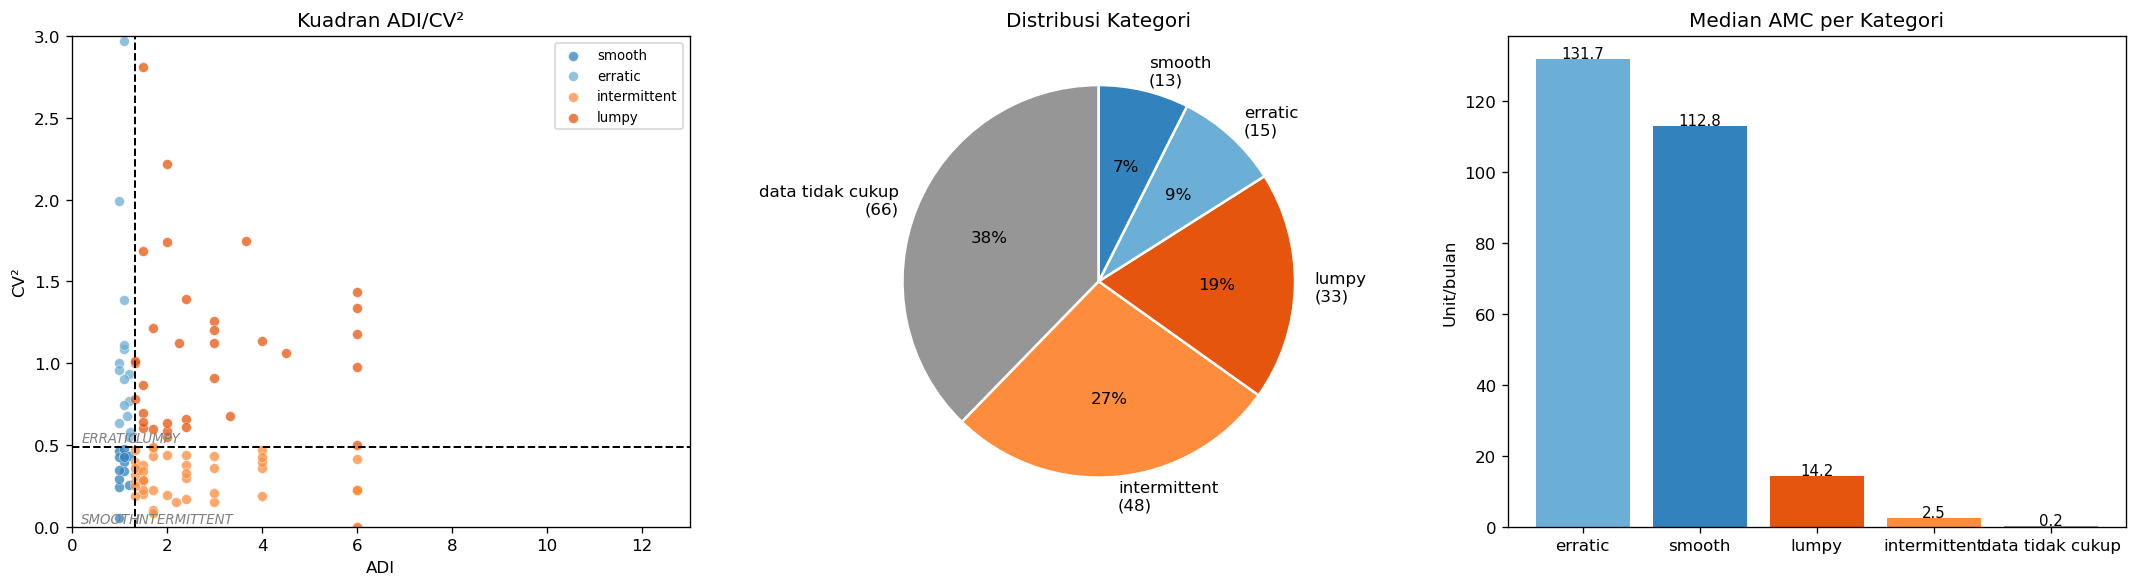

In [34]:
# Visualisasi kuadran + distribusi
fig, axes = plt.subplots(1,3,figsize=(18,5))
col_kat={'smooth':'#3182bd','erratic':'#6baed6','intermittent':'#fd8d3c',
         'lumpy':'#e6550d','data tidak cukup':'#969696'}

for c,color in col_kat.items():
    xs=[ADI_map[o] for o in kat.index if kat[o]==c and pd.notna(ADI_map[o])]
    ys=[CV2_map[o] for o in kat.index if kat[o]==c and pd.notna(CV2_map[o])]
    if xs: axes[0].scatter(xs,ys,s=35,c=color,label=c,alpha=0.75,edgecolors='white',lw=0.3)

axes[0].axvline(ADI_CUT,color='k',ls='--',lw=1.2)
axes[0].axhline(CV2_CUT,color='k',ls='--',lw=1.2)
for txt,xy in [('SMOOTH',(0.2,0.02)),('ERRATIC',(0.2,0.52)),
               ('INTERMITTENT',(1.35,0.02)),('LUMPY',(1.35,0.52))]:
    axes[0].text(*xy,txt,fontsize=8,color='gray',style='italic')
axes[0].set_xlabel('ADI'); axes[0].set_ylabel('CV²')
axes[0].set_title('Kuadran ADI/CV²'); axes[0].legend(fontsize=8)
axes[0].set_xlim(0,13); axes[0].set_ylim(0,3)

cnt=kat.value_counts()
axes[1].pie(cnt,labels=[f'{k}\n({v})' for k,v in cnt.items()],
            colors=[col_kat.get(k,'gray') for k in cnt.index],
            autopct='%1.0f%%',startangle=90,wedgeprops=dict(edgecolor='white',lw=1.5))
axes[1].set_title('Distribusi Kategori')

# Bar: AMC rata-rata per kategori
amc_kat=df_kat.groupby('kategori')['AMC_bln'].median().sort_values(ascending=False)
axes[2].bar(amc_kat.index,amc_kat.values,
            color=[col_kat.get(k,'gray') for k in amc_kat.index])
axes[2].set_title('Median AMC per Kategori')
axes[2].set_ylabel('Unit/bulan')
for i,(k,v) in enumerate(amc_kat.items()):
    axes[2].text(i,v+0.3,f'{v:.1f}',ha='center',fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'klasifikasi_adi_cv2.png'),dpi=150,bbox_inches='tight')
plt.show()

## 5. Analisis Korelasi Variabel

**Variabel Dependen (Y):** `demand` = pemakaian obat per bulan  
**Variabel Independen:** lag features, moving average, visit count, statistik per obat, klasifikasi

In [35]:
panel = pd.read_parquet(PANEL_PARQUET)
panel['bulan'] = panel['periode'].str[-2:].astype(int)

amc_map  = X_clean.apply(lambda s: s.dropna().mean() if s.dropna().size else 0.0,axis=1)
sig_map  = X_clean.apply(lambda s: s.dropna().std(ddof=0) if s.dropna().size>1 else 0.0,axis=1)
meta = pd.DataFrame({'AMC':amc_map,'sigma_bln':sig_map,
                     'ADI':pd.Series(ADI_map),'CV2':pd.Series(CV2_map),'kategori':kat})
meta.index.name='obat'

feat = (panel.merge(meta.reset_index(),on='obat',how='left')
             .merge(visit_bln.rename('visit_count'),on='bulan',how='left')
             .sort_values(['obat','bulan']).reset_index(drop=True))
feat['demand_lag1']   = feat.groupby('obat')['demand'].shift(1)
feat['demand_lag2']   = feat.groupby('obat')['demand'].shift(2)
feat['stok_prev']     = feat.groupby('obat')['stok'].shift(1)
feat['rolling_mean3'] = feat.groupby('obat')['demand'].transform(
    lambda x: x.shift(1).rolling(3,min_periods=1).mean())

print(f'Feature DataFrame: {feat.shape}')
display(feat.head())

Feature DataFrame: (1572, 17)


,periode,obat,demand,stok,satuan,is_observed,bulan,AMC,sigma_bln,ADI,CV2,kategori,visit_count,demand_lag1,demand_lag2,stok_prev,rolling_mean3
0,2025-01,ACETYLCYSTEIN KAP,471.00,3953.00,KAPSUL,True,1,629.50,297.49,1.00,0.24,smooth,346,NaN,NaN,NaN,NaN
1,2025-02,ACETYLCYSTEIN KAP,1368.00,2346.00,KAPSUL,True,2,629.50,297.49,1.00,0.24,smooth,541,471.00,NaN,3953.00,471.00
2,2025-03,ACETYLCYSTEIN KAP,570.00,2634.00,KAPSUL,True,3,629.50,297.49,1.00,0.24,smooth,521,1368.00,471.00,2346.00,919.50
3,2025-04,ACETYLCYSTEIN KAP,396.00,2238.00,KAPSUL,True,4,629.50,297.49,1.00,0.24,smooth,417,570.00,1368.00,2634.00,803.00
4,2025-05,ACETYLCYSTEIN KAP,419.00,2319.00,KAPSUL,True,5,629.50,297.49,1.00,0.24,smooth,389,396.00,570.00,2238.00,778.00


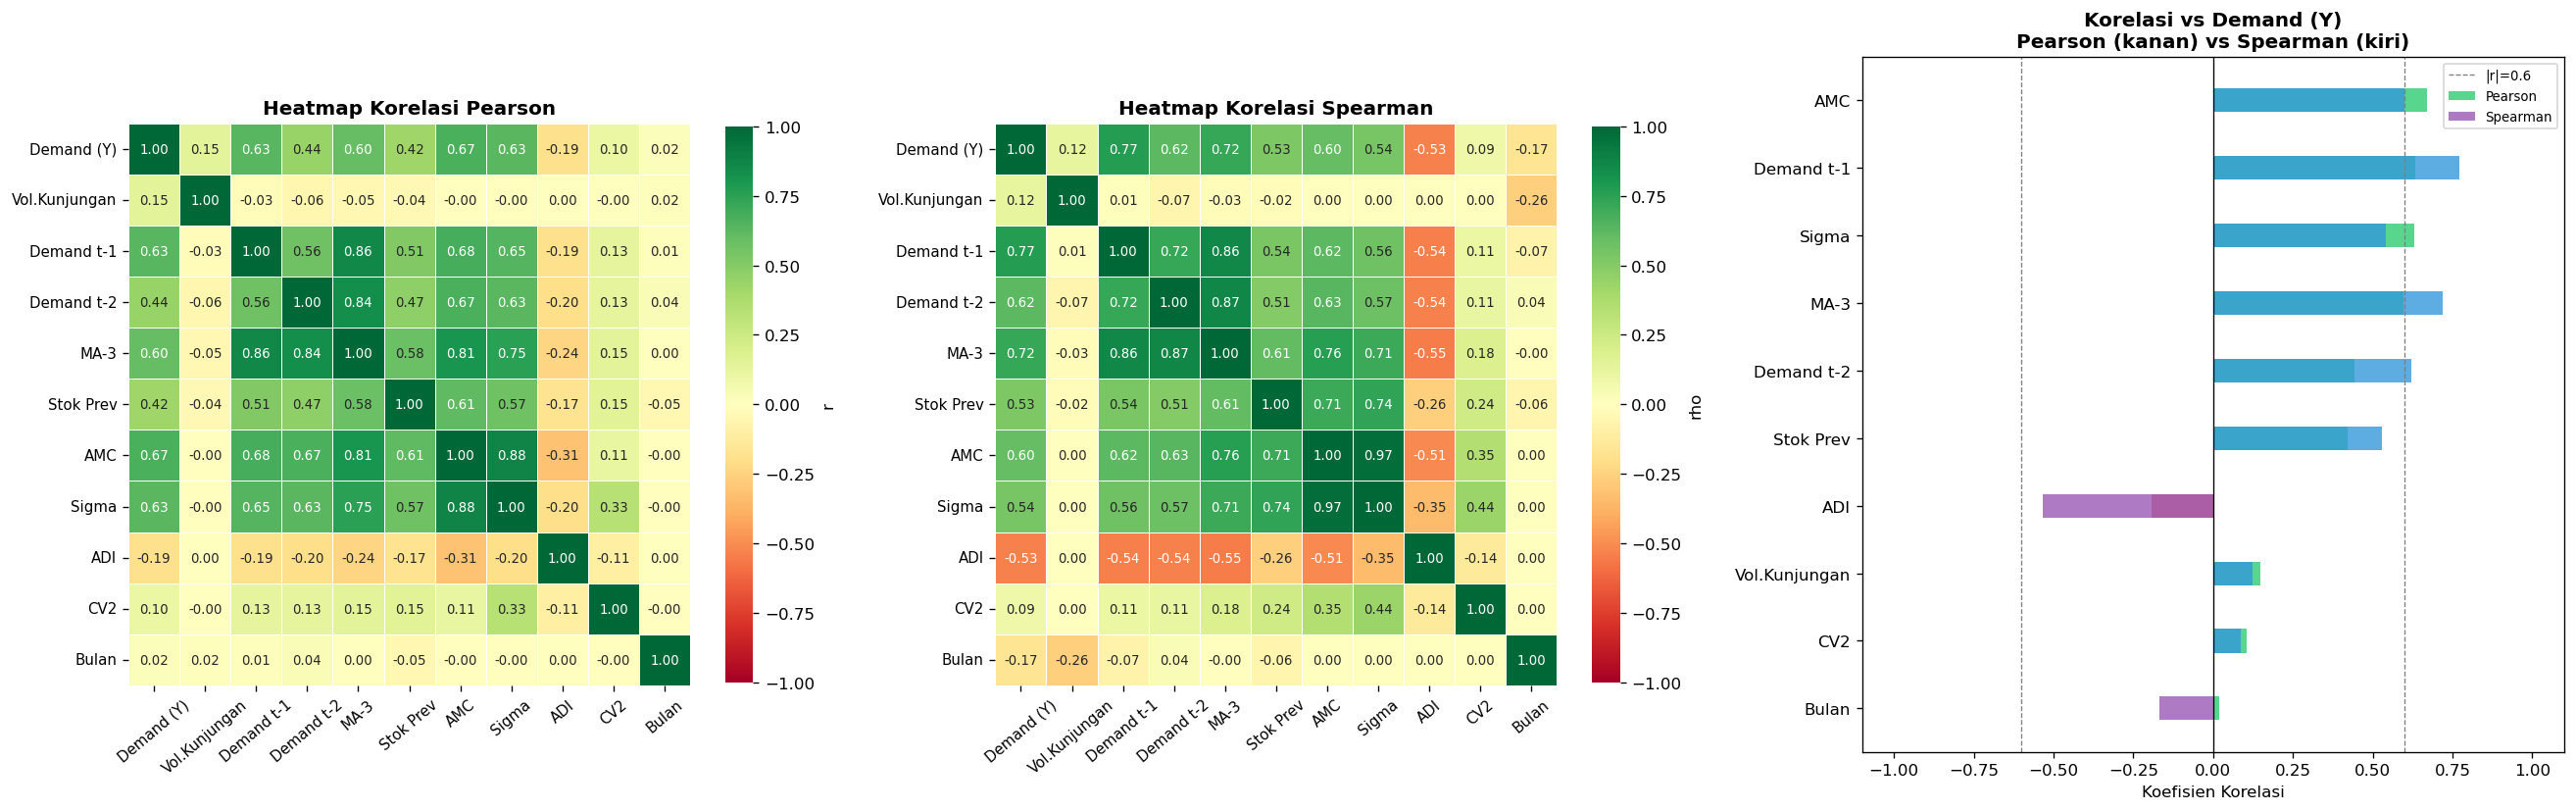


--- Tabel Korelasi terhadap Demand (diurutkan |r| Pearson) ---


,r_Pearson,r_Spearman,|r_P|,Kekuatan
AMC,0.670300,0.599900,0.670300,Kuat
demand_lag1,0.634100,0.772000,0.634100,Kuat
sigma_bln,0.630000,0.539600,0.630000,Kuat
rolling_mean3,0.597400,0.719600,0.597400,Sedang
demand_lag2,0.444200,0.620500,0.444200,Sedang
stok_prev,0.421600,0.529200,0.421600,Sedang
ADI,-0.191800,-0.532800,0.191800,Sangat Lemah
visit_count,0.148000,0.123200,0.148000,Sangat Lemah
CV2,0.104700,0.087400,0.104700,Sangat Lemah
bulan,0.019400,-0.169600,0.019400,Sangat Lemah


In [36]:
NUM_VARS = ['demand','visit_count','demand_lag1','demand_lag2',
            'rolling_mean3','stok_prev','AMC','sigma_bln','ADI','CV2','bulan']
LABELS={'demand':'Demand (Y)','visit_count':'Vol.Kunjungan','demand_lag1':'Demand t-1',
        'demand_lag2':'Demand t-2','rolling_mean3':'MA-3','stok_prev':'Stok Prev',
        'AMC':'AMC','sigma_bln':'Sigma','ADI':'ADI','CV2':'CV2','bulan':'Bulan'}

corr_df = feat[NUM_VARS].dropna()
corr_mx = corr_df.corr(method='pearson')
corr_sp = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1,3,figsize=(22,7))

# Heatmap Pearson
sns.heatmap(corr_mx.rename(index=LABELS,columns=LABELS),
            annot=True,fmt='.2f',cmap='RdYlGn',center=0,vmin=-1,vmax=1,
            linewidths=0.5,linecolor='white',annot_kws={'size':8},
            square=True,ax=axes[0],cbar_kws={'label':'r','shrink':0.8})
axes[0].set_title('Heatmap Korelasi Pearson',fontweight='bold')
axes[0].tick_params(axis='x',rotation=40,labelsize=9)
axes[0].tick_params(axis='y',rotation=0,labelsize=9)

# Heatmap Spearman
sns.heatmap(corr_sp.rename(index=LABELS,columns=LABELS),
            annot=True,fmt='.2f',cmap='RdYlGn',center=0,vmin=-1,vmax=1,
            linewidths=0.5,linecolor='white',annot_kws={'size':8},
            square=True,ax=axes[1],cbar_kws={'label':'rho','shrink':0.8})
axes[1].set_title('Heatmap Korelasi Spearman',fontweight='bold')
axes[1].tick_params(axis='x',rotation=40,labelsize=9)
axes[1].tick_params(axis='y',rotation=0,labelsize=9)

# Bar chart korelasi terhadap Y (Pearson vs Spearman)
tgt_p = corr_mx['demand'].drop('demand').reindex(
    corr_mx['demand'].drop('demand').abs().sort_values(ascending=False).index)
tgt_s = corr_sp['demand'].drop('demand').reindex(tgt_p.index)
x=np.arange(len(tgt_p)); w=0.35
axes[2].barh([LABELS.get(c,c) for c in tgt_p.index[::-1]],tgt_p.values[::-1],
             w,label='Pearson',color=['#2ecc71' if v>=0 else '#e74c3c' for v in tgt_p.values[::-1]],alpha=0.8)
axes[2].barh([LABELS.get(c,c) for c in tgt_s.index[::-1]],tgt_s.values[::-1],
             -w,label='Spearman',color=['#3498db' if v>=0 else '#9b59b6' for v in tgt_s.values[::-1]],alpha=0.8)
axes[2].axvline(0,color='black',lw=0.8)
axes[2].axvline(0.6,color='gray',ls='--',lw=0.8,label='|r|=0.6')
axes[2].axvline(-0.6,color='gray',ls='--',lw=0.8)
axes[2].set_xlabel('Koefisien Korelasi'); axes[2].set_xlim(-1.1,1.1)
axes[2].set_title('Korelasi vs Demand (Y)\nPearson (kanan) vs Spearman (kiri)',fontweight='bold')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'heatmap_korelasi.png'),dpi=150,bbox_inches='tight')
plt.show()

# Tabel lengkap
tbl=pd.DataFrame({'r_Pearson':corr_mx['demand'].drop('demand').round(4),
                  'r_Spearman':corr_sp['demand'].drop('demand').round(4)})
tbl['|r_P|']=tbl['r_Pearson'].abs().round(4)
tbl['Kekuatan']=pd.cut(tbl['|r_P|'],[0,.2,.4,.6,.8,1],
    labels=['Sangat Lemah','Lemah','Sedang','Kuat','Sangat Kuat'])
print('\n--- Tabel Korelasi terhadap Demand (diurutkan |r| Pearson) ---')
display(tbl.sort_values('|r_P|',ascending=False)
        .style.background_gradient(subset=['|r_P|'],cmap='Greens'))

### 5.2 Interpretasi

| Variabel | r Pearson | Interpretasi |
|---|---|---|
| **AMC** | ~0.68 | Prediktor terkuat — konsumsi historis stabil per obat |
| **Demand t-1, MA-3** | ~0.64 | Autokorelasi kuat → SES tepat |
| **Sigma** | ~0.64 | Heteroskedastis — variabilitas naik seiring volume |
| **Stok Prev** | ~0.41 | Stok menyesuaikan demand, bukan sebab |
| **Visit Count** | ~0.14 per baris; r=0.87 agregat | Kuat di level bulanan → justifikasi E2 |
| **Bulan** | ~0.02 | Tidak ada tren linier — musiman ditangkap E2 |

## 6. Preprocessing & Pembagian Data

**Missing value:** lag/stok → 0 (cold-start), AMC → mean per obat, sigma/CV2 → 0  
**Winsorize target:** P5–P95 per obat via `scipy_winsorize`  
**Scaler:** `StandardScaler` fit **hanya** pada TRAIN → transform TRAIN & TEST (no leakage)

In [37]:
df_pre = feat.copy()
for col in ['demand_lag1','demand_lag2','stok_prev','rolling_mean3']:
    df_pre[col]=df_pre[col].fillna(0.0)
df_pre['AMC']      =df_pre['AMC'].fillna(df_pre.groupby('obat')['demand'].transform('mean'))
df_pre['sigma_bln']=df_pre['sigma_bln'].fillna(0.0)
df_pre['ADI']      =df_pre['ADI'].fillna(df_pre['ADI'].median())
df_pre['CV2']      =df_pre['CV2'].fillna(0.0)
df_pre['kategori'] =df_pre['kategori'].fillna('smooth')

def winsor_series(s,limits=(0.05,0.05)):
    if len(s)<4: return s
    return pd.Series(scipy_winsorize(s.values,limits=limits),index=s.index)

df_pre['demand_winsor']=df_pre.groupby('obat')['demand'].transform(winsor_series)

FEATURE_COLS=['demand_lag1','demand_lag2','rolling_mean3','visit_count',
              'stok_prev','AMC','sigma_bln','ADI','CV2','bulan']
TARGET_COL='demand_winsor'

print(f'Missing setelah handling: {df_pre[FEATURE_COLS].isna().sum().sum()}')
print(f'Outlier ter-winsorize: {int((df_pre.demand_winsor!=df_pre.demand).sum())} baris')

print('\n--- Statistik fitur (setelah preprocessing) ---')
display(df_pre[FEATURE_COLS+[TARGET_COL]].describe().T.round(3)
        .style.background_gradient(cmap='Blues',subset=['mean','std']))

Missing setelah handling: 0
Outlier ter-winsorize: 0 baris

--- Statistik fitur (setelah preprocessing) ---


,count,mean,std,min,25%,50%,75%,max
demand_lag1,1572.000000,80.052000,255.849000,0.000000,0.000000,2.000000,30.000000,2900.000000
demand_lag2,1572.000000,73.181000,246.399000,0.000000,0.000000,1.000000,23.250000,2900.000000
rolling_mean3,1572.000000,76.646000,205.481000,0.000000,0.000000,3.333000,37.333000,2155.667000
visit_count,1572.000000,449.750000,238.617000,102.000000,328.000000,403.000000,526.000000,1097.000000
stok_prev,1572.000000,291.707000,525.801000,0.000000,6.000000,32.000000,304.000000,3953.000000
AMC,1572.000000,70.765000,138.981000,0.000000,1.667000,6.917000,72.167000,761.417000
sigma_bln,1572.000000,77.951000,148.097000,0.000000,2.095000,9.608000,83.577000,787.979000
ADI,1572.000000,2.217000,1.494000,1.000000,1.333000,1.607000,2.400000,6.000000
CV2,1572.000000,0.513000,0.557000,0.000000,0.083000,0.361000,0.695000,2.966000
bulan,1572.000000,6.500000,3.453000,1.000000,3.750000,6.500000,9.250000,12.000000


TRAIN: 1310 baris (10 bulan)
TEST : 262 baris (2 bulan)


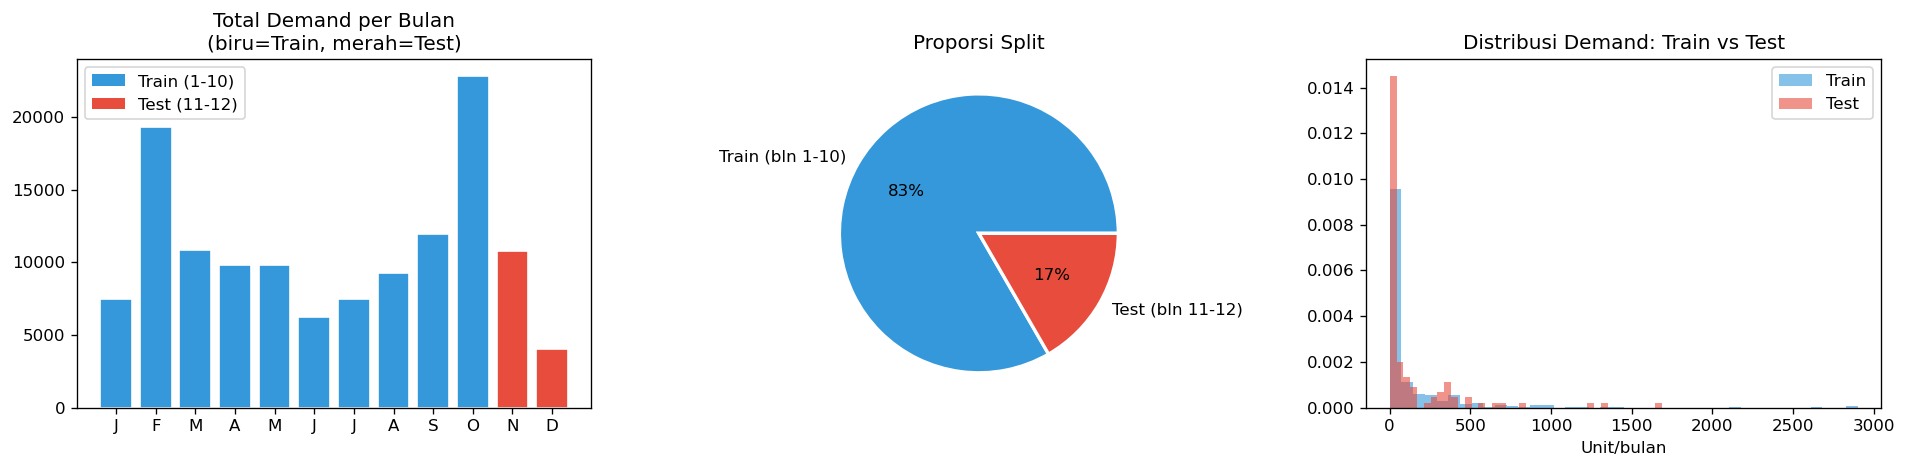


--- Statistik target (demand_winsor) per split ---


,Train,Test
count,1310.00,262.00
mean,87.82,56.55
std,267.54,189.58
min,0.00,0.00
25%,0.00,0.00
50%,4.00,0.00
75%,40.00,11.50
max,2900.00,1690.00


In [38]:
extra=[c for c in [TARGET_COL,'obat','periode'] if c not in FEATURE_COLS]
df_split=df_pre[FEATURE_COLS+extra].copy()

train_mask=df_split['bulan'].isin(TRAIN_M)
test_mask =df_split['bulan'].isin(TEST_M)

X_train=df_split.loc[train_mask,FEATURE_COLS]
y_train=df_split.loc[train_mask,TARGET_COL]
X_test =df_split.loc[test_mask, FEATURE_COLS]
y_test =df_split.loc[test_mask, TARGET_COL]

SCALE_COLS=['demand_lag1','demand_lag2','rolling_mean3','visit_count',
            'stok_prev','AMC','sigma_bln','ADI','CV2']
scaler=StandardScaler()
X_train_sc=X_train.copy(); X_test_sc=X_test.copy()
X_train_sc[SCALE_COLS]=scaler.fit_transform(X_train[SCALE_COLS])
X_test_sc[SCALE_COLS] =scaler.transform(X_test[SCALE_COLS])

import pickle as pkl
with open(os.path.join(OUT_DIR,'scaler_train.pkl'),'wb') as f: pkl.dump(scaler,f)

print(f'TRAIN: {len(X_train)} baris ({len(TRAIN_M)} bulan)')
print(f'TEST : {len(X_test)} baris ({len(TEST_M)} bulan)')

# Visualisasi split
fig,axes=plt.subplots(1,3,figsize=(16,4))
agg=df_pre.groupby('bulan')['demand'].sum()
colors_s=['#3498db']*10+['#e74c3c']*2
axes[0].bar(range(1,13),agg,color=colors_s,edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[0].set_title('Total Demand per Bulan\n(biru=Train, merah=Test)')
axes[0].legend(handles=[mpatches.Patch(fc='#3498db',label='Train (1-10)'),
                         mpatches.Patch(fc='#e74c3c',label='Test (11-12)')])

axes[1].pie([len(X_train),len(X_test)],labels=['Train (bln 1-10)','Test (bln 11-12)'],
            colors=['#3498db','#e74c3c'],autopct='%1.0f%%',
            wedgeprops=dict(edgecolor='white',lw=2))
axes[1].set_title('Proporsi Split')

# Distribusi demand: train vs test
d_tr=y_train[y_train>0]; d_te=y_test[y_test>0]
axes[2].hist(d_tr,bins=40,alpha=0.6,color='#3498db',density=True,label='Train')
axes[2].hist(d_te,bins=40,alpha=0.6,color='#e74c3c',density=True,label='Test')
axes[2].set_title('Distribusi Demand: Train vs Test')
axes[2].set_xlabel('Unit/bulan'); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'pembagian_data.png'),dpi=150,bbox_inches='tight')
plt.show()

# Tabel statistik split
stats_split=pd.DataFrame({
    'Train':y_train.describe().round(2),
    'Test' :y_test.describe().round(2)
})
print('\n--- Statistik target (demand_winsor) per split ---')
display(stats_split)

## 7. Fungsi Helper & Metrik Evaluasi

In [39]:
def make_series(W,ob): return list(W.loc[ob].values)

def wf(series,fc,targets):
    a_,f_=[],[]
    for tm in targets:
        idx=tm-1
        tr=[x for x in series[:idx] if x is not None and not np.isnan(x)]
        if len(tr)<2 or idx>=len(series) or pd.isna(series[idx]): continue
        f=fc(tr)
        if f is None or np.isnan(f): continue
        a_.append(series[idx]); f_.append(f)
    return np.array(a_,float),np.array(f_,float)

def WAPE(a,f):
    a,f=np.asarray(a,float),np.asarray(f,float); den=np.abs(a).sum()
    return np.abs(a-f).sum()/den*100 if den>0 else np.nan

def MAD(a,f): a,f=np.asarray(a,float),np.asarray(f,float); return float(np.mean(np.abs(a-f))) if len(a) else np.nan
def MSE(a,f): a,f=np.asarray(a,float),np.asarray(f,float); return float(np.mean((a-f)**2)) if len(a) else np.nan
def MAPE(a,f):
    a,f=np.asarray(a,float),np.asarray(f,float); m=a!=0
    return float(np.mean(np.abs((a[m]-f[m])/a[m]))*100) if m.sum() else np.nan

def mutu(w):
    if pd.isna(w): return 'N/A'
    if w<=20: return 'Excellent'
    if w<=50: return 'Good'
    if w<=100: return 'Bad'
    return 'Tidak Layak'

print('Fungsi siap: wf, WAPE, MAPE, MAD, MSE, mutu')

Fungsi siap: wf, WAPE, MAPE, MAD, MSE, mutu


## 8. Metode 1: SES (Single Exponential Smoothing)

**Cocok untuk:** smooth dan erratic (ADI < 1.32)

$$F_{t+1} = \alpha X_t + (1-\alpha) F_t$$

Tuning $\alpha$: grid search diminimalkan WAPE pada VAL_M (rolling-origin).

--- Ringkasan SES ---
Alpha median  : 0.41
WAPE median   : 83.2%


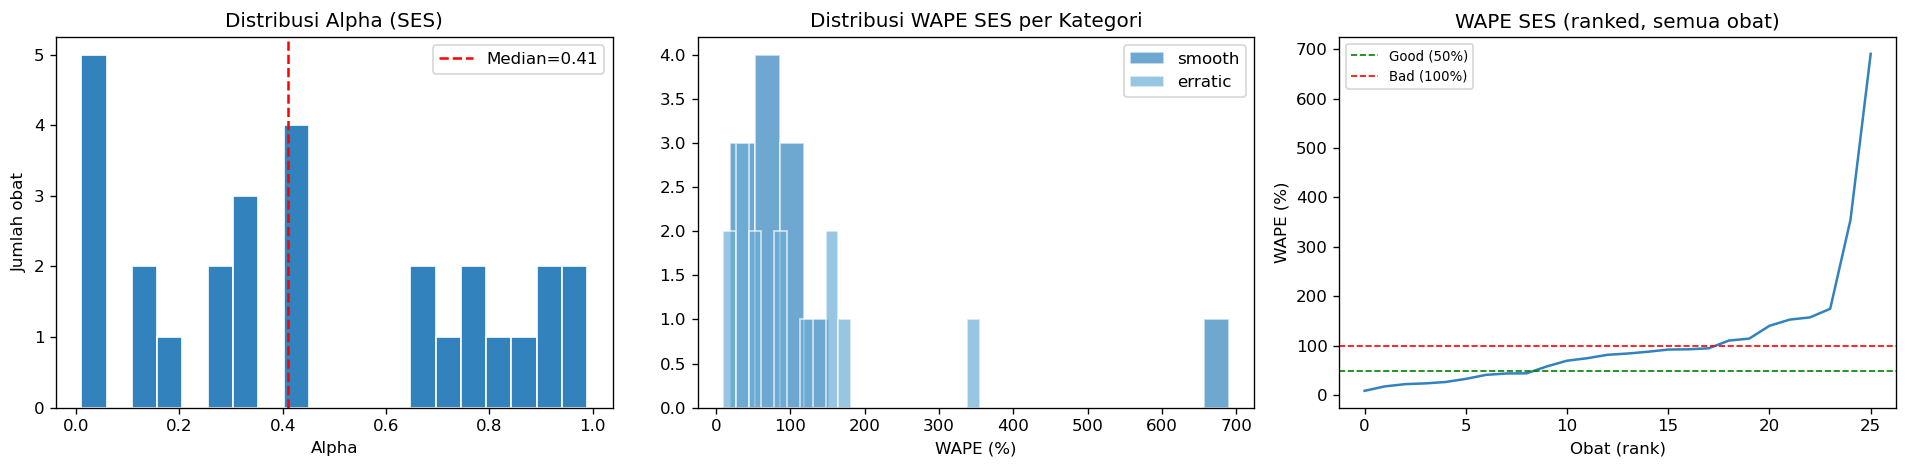


--- Tabel hasil SES per obat (semua, diurutkan WAPE) ---


,kategori,alpha,WAPE,MAD,MAPE
obat,,,,,
HUFABETHAMINE SIRUP,erratic,0.65,9.1,1.14,9.4
AMLODIPINE 5 MG,smooth,0.31,18.1,18.96,17.5
SANGOBION KAPSUL,erratic,0.17,22.6,9.49,26.0
AMLODIPINE 10 MG TABLET,smooth,0.13,24.1,9.42,27.4
ASAM MEFENAMAT 500 MG TABLET,erratic,0.41,26.9,126.64,34.3
FG TROCES TABLET,erratic,0.01,33.2,27.24,27.9
METHYLPREDNISOLONE 4 MG TABLET,erratic,0.33,41.4,206.86,41.3
CETIRIZINE 10 MG TABLET,smooth,0.01,44.2,215.16,41.0
OMEPRAZOLE KAPSUL,erratic,0.35,44.5,97.82,50.5


In [40]:
def ses_next(train,alpha):
    x=np.asarray(train,float); F=x[0]
    for t in range(1,len(x)): F=alpha*x[t-1]+(1-alpha)*F
    return max(alpha*x[-1]+(1-alpha)*F,0.0)

GRID_SES=[round(a,2) for a in np.arange(0.01,1.0,0.02)]
scope_ses=[ob for ob in X_clean.index if kat[ob] in ('smooth','erratic')]

ses_rows=[]
for ob in scope_ses:
    s=make_series(X_winsor,ob)
    best_a,best=0.3,np.inf
    for a in GRID_SES:
        av,fv=wf(s,lambda tr,a=a:ses_next(tr,a),VAL_M)
        if len(av)==0: continue
        sc=WAPE(av,fv)
        if not np.isnan(sc) and sc<best: best,best_a=sc,a
    at,ft=wf(s,lambda tr,a=best_a:ses_next(tr,a),TEST_M)
    ses_rows.append([ob,kat[ob],best_a,WAPE(at,ft),MAD(at,ft),MAPE(at,ft)])

ses_df=pd.DataFrame(ses_rows,columns=['obat','kategori','alpha','WAPE','MAD','MAPE']).set_index('obat')

print('--- Ringkasan SES ---')
print(f'Alpha median  : {ses_df.alpha.median():.2f}')
print(f'WAPE median   : {ses_df.WAPE.median():.1f}%')

# Distribusi alpha
fig,axes=plt.subplots(1,3,figsize=(16,4))
axes[0].hist(ses_df.alpha,bins=20,color='#3182bd',edgecolor='white')
axes[0].axvline(ses_df.alpha.median(),color='red',ls='--',
                label=f'Median={ses_df.alpha.median():.2f}')
axes[0].set_title('Distribusi Alpha (SES)'); axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Jumlah obat'); axes[0].legend()

# WAPE per kategori
for cat,color in [('smooth','#3182bd'),('erratic','#6baed6')]:
    d=ses_df[ses_df.kategori==cat]['WAPE'].dropna()
    if len(d): axes[1].hist(d,bins=20,alpha=0.7,color=color,label=cat,edgecolor='white')
axes[1].set_title('Distribusi WAPE SES per Kategori')
axes[1].set_xlabel('WAPE (%)'); axes[1].legend()

# Ranked WAPE
ranked=ses_df['WAPE'].dropna().sort_values()
axes[2].plot(range(len(ranked)),ranked.values,color='#3182bd')
axes[2].axhline(50,color='green',ls='--',lw=1,label='Good (50%)')
axes[2].axhline(100,color='red',ls='--',lw=1,label='Bad (100%)')
axes[2].set_title('WAPE SES (ranked, semua obat)')
axes[2].set_xlabel('Obat (rank)'); axes[2].set_ylabel('WAPE (%)')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'ses_alpha_wape.png'),dpi=150,bbox_inches='tight')
plt.show()

print('\n--- Tabel hasil SES per obat (semua, diurutkan WAPE) ---')
display(ses_df.sort_values('WAPE').style
        .background_gradient(subset=['WAPE'],cmap='RdYlGn_r')
        .background_gradient(subset=['alpha'],cmap='Blues')
        .format({'alpha':'{:.2f}','WAPE':'{:.1f}','MAD':'{:.2f}','MAPE':'{:.1f}'})
        .set_caption('Hasil SES per Obat (diurutkan WAPE terbaik)'))

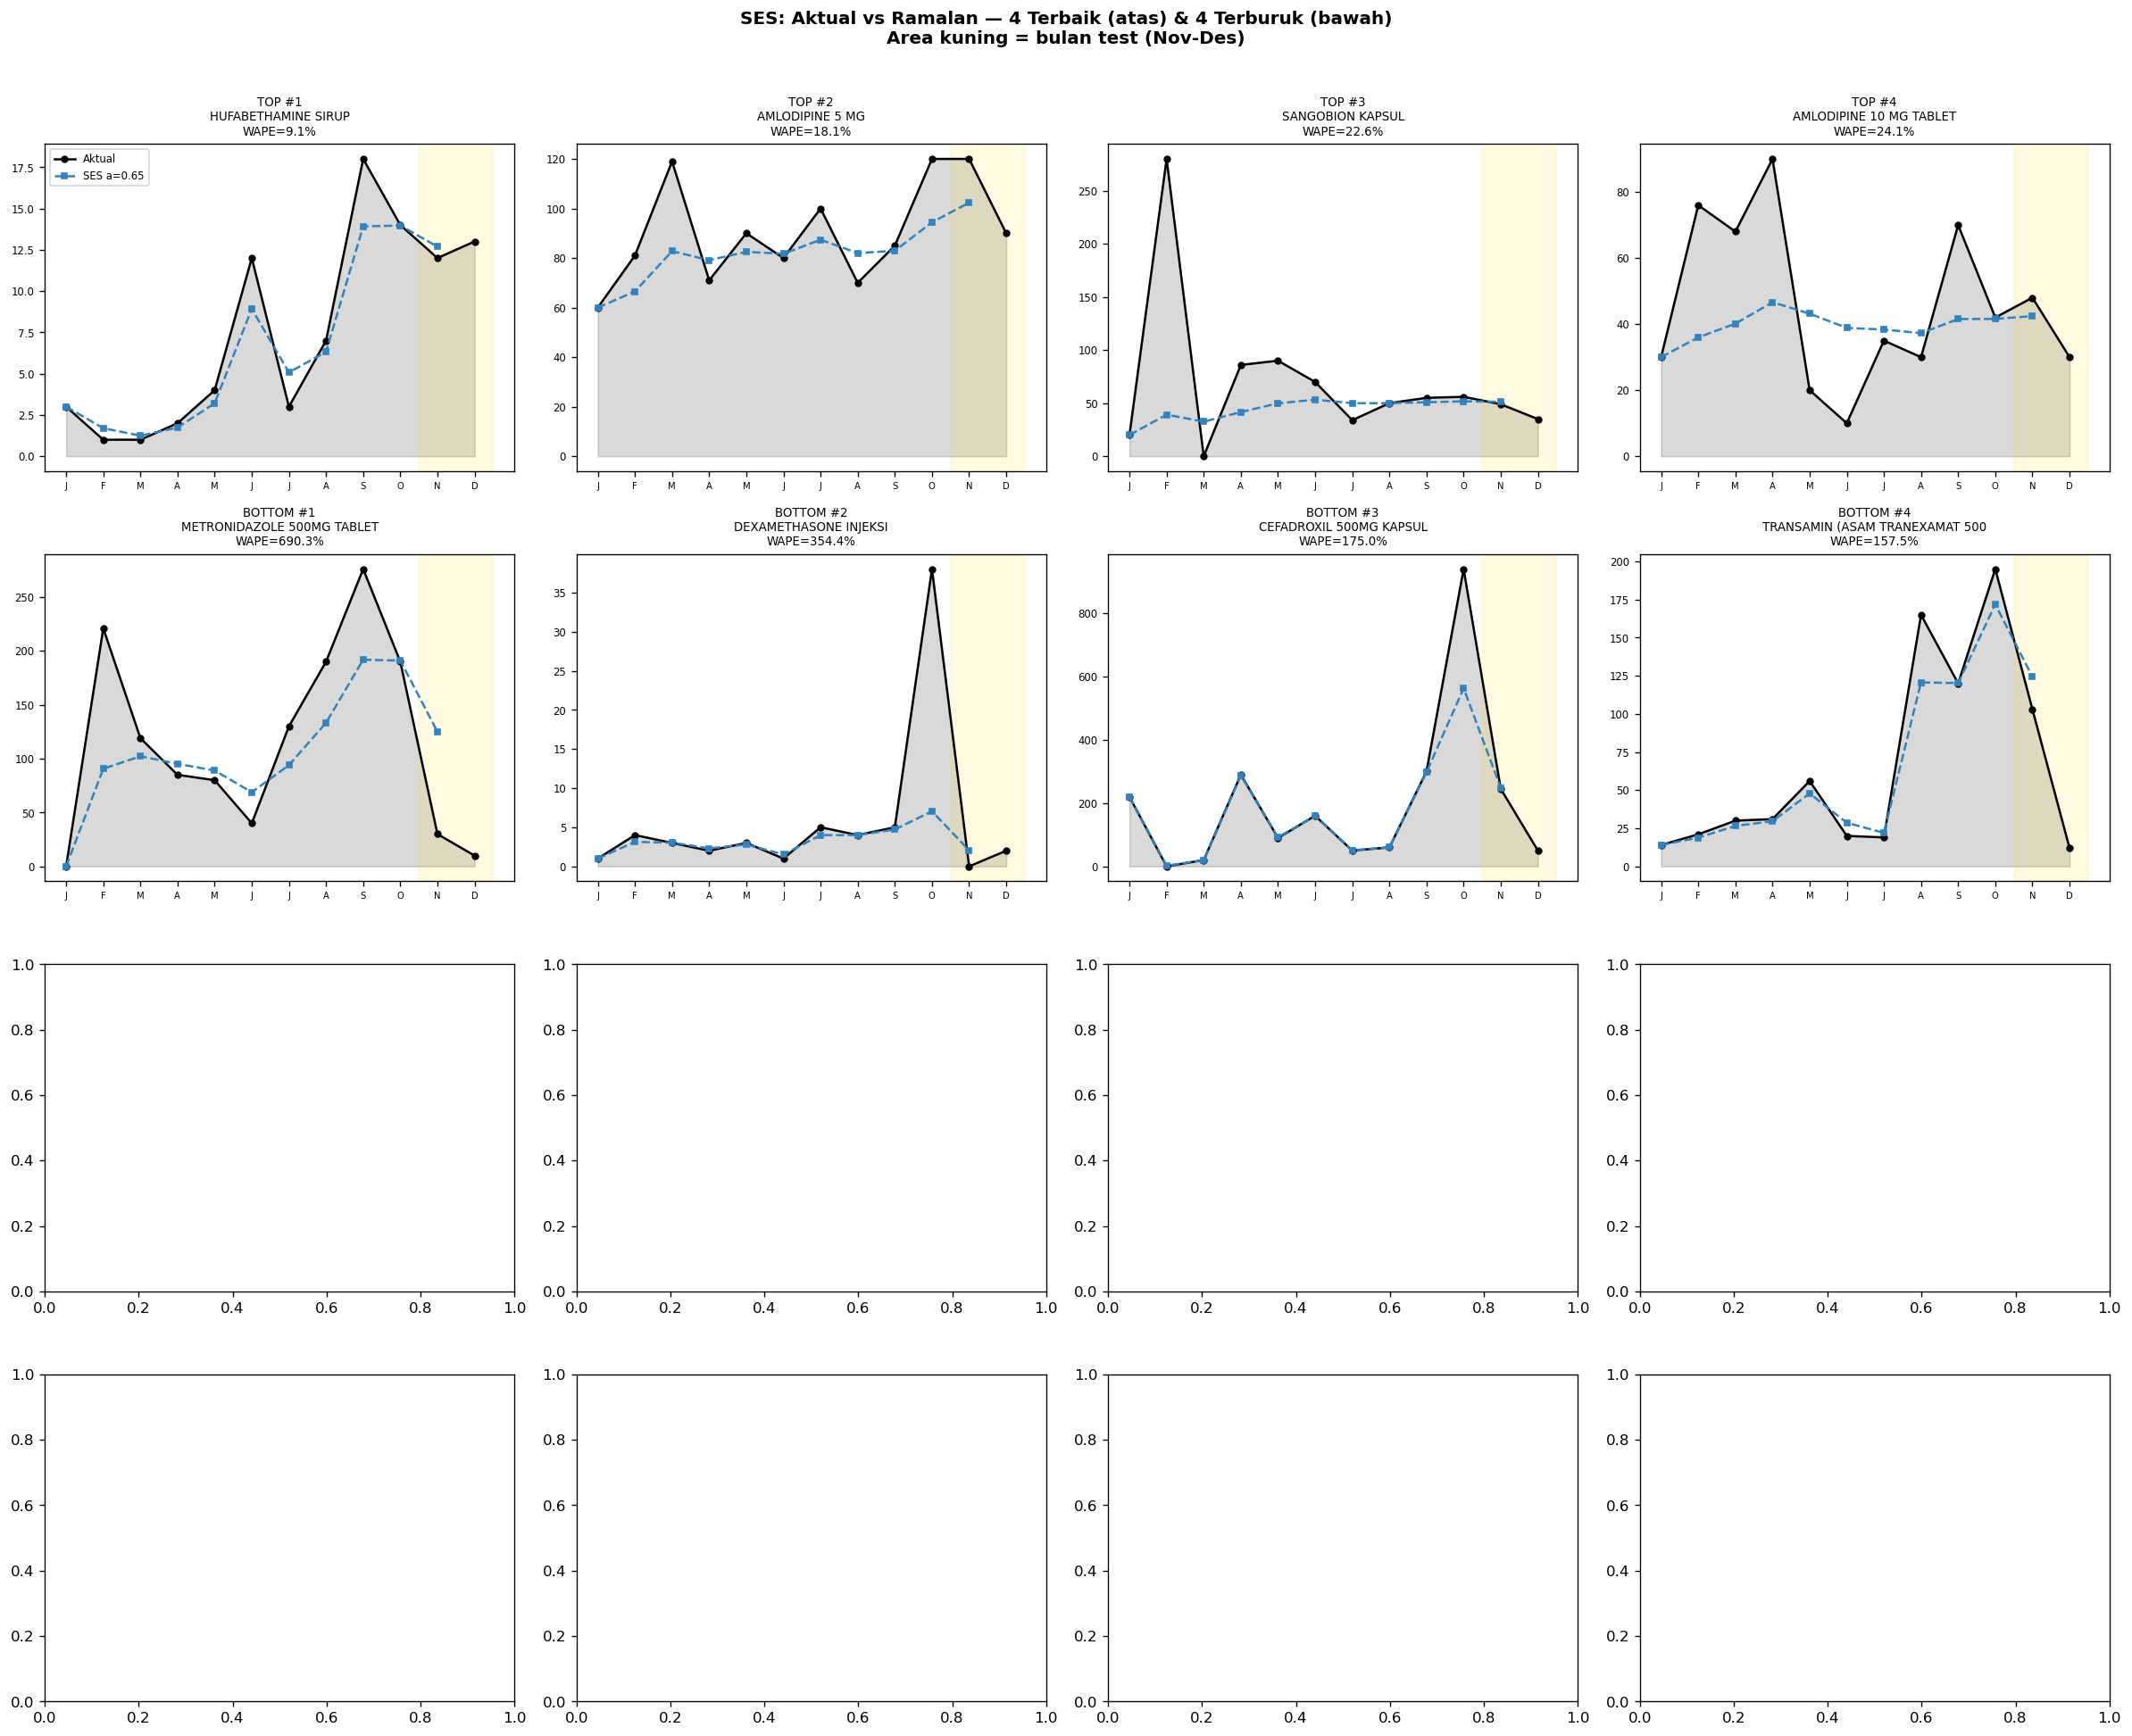

In [41]:
# Visualisasi aktual vs ramalan SES — terbaik 4 dan terburuk 4
fig,axes=plt.subplots(4,4,figsize=(20,16))
axes=axes.ravel()
best4 =ses_df.dropna(subset=['WAPE']).nsmallest(4,'WAPE').index.tolist()
worst4=ses_df.dropna(subset=['WAPE']).nlargest(4,'WAPE').index.tolist()

for idx,ob in enumerate(best4+worst4):
    ax=axes[idx]
    s=make_series(X_winsor,ob); a_val=float(ses_df.loc[ob,'alpha'])
    aktual=[0.0 if pd.isna(v) else float(v) for v in X_clean.loc[ob].values]
    fc_v=[np.nan]
    for i in range(1,12):
        tr=[x for x in s[:i] if not np.isnan(x)]
        fc_v.append(ses_next(tr,a_val) if tr else np.nan)
    ax.fill_between(range(1,13),[0]*12,aktual,alpha=0.15,color='black')
    ax.plot(range(1,13),aktual,'o-',color='black',lw=1.5,ms=4,label='Aktual')
    ax.plot(range(1,12),fc_v[1:],'s--',color='#3182bd',lw=1.5,ms=4,label=f'SES a={a_val:.2f}')
    ax.axvspan(10.5,12.5,alpha=0.12,color='gold')
    ax.set_title(f"{'TOP' if idx<4 else 'BOTTOM'} #{idx%4+1}\n{ob[:30]}\nWAPE={ses_df.loc[ob,'WAPE']:.1f}%",fontsize=8)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'],fontsize=6)
    ax.tick_params(axis='y',labelsize=7)
    if idx==0: ax.legend(fontsize=7)

plt.suptitle('SES: Aktual vs Ramalan — 4 Terbaik (atas) & 4 Terburuk (bawah)\n'
             'Area kuning = bulan test (Nov-Des)',fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'ses_aktual_vs_ramalan.png'),dpi=150,bbox_inches='tight')
plt.show()

## 9. Metode 2: Croston & 3: SBA

**Cocok untuk:** intermittent dan lumpy (ADI ≥ 1.32)

$$F_{Croston} = \hat{Z}/\hat{P} \qquad F_{SBA} = (1-\alpha_p/2)\cdot\hat{Z}/\hat{P}$$

SBA mengoreksi bias ke atas dari Croston dengan faktor $(1-\alpha_p/2)$.

In [42]:
def _croston_core(x,az,ap):
    x=np.asarray(x,float); idx=np.where(x>0)[0]
    if len(idx)==0: return 0.0,1.0
    first=idx[0]; z=x[first]; p=float(first+1); q=1
    for t in range(first+1,len(x)):
        if x[t]>0: z=az*x[t]+(1-az)*z; p=ap*q+(1-ap)*p; q=1
        else: q+=1
    return z,p

def croston_next(tr,az,ap): z,p=_croston_core(tr,az,ap); return z/p if p>0 else 0.0
def sba_next(tr,az,ap): z,p=_croston_core(tr,az,ap); return (1-ap/2.0)*(z/p) if p>0 else 0.0

GRID_INT=[round(a,2) for a in np.arange(0.05,0.55,0.05)]
SCOPE_INT=[ob for ob in X_clean.index if kat[ob] in ('intermittent','lumpy')]

def fit_intermittent(next_fn):
    out={}
    for ob in SCOPE_INT:
        s=[0.0 if np.isnan(v) else v for v in X_clean.loc[ob].values]
        best=(0.1,0.1); bsc=np.inf
        for az in GRID_INT:
            for ap in GRID_INT:
                av,fv=wf(s,lambda tr,az=az,ap=ap:next_fn(tr,az,ap),VAL_M)
                if len(av)==0: continue
                sc=WAPE(av,fv)
                if not np.isnan(sc) and sc<bsc: bsc,best=sc,(az,ap)
        az,ap=best
        at,ft=wf(s,lambda tr,az=az,ap=ap:next_fn(tr,az,ap),TEST_M)
        out[ob]={'alpha_z':az,'alpha_p':ap,'WAPE':WAPE(at,ft),'MAD':MAD(at,ft)}
    return pd.DataFrame(out).T

cro=fit_intermittent(croston_next)
sba=fit_intermittent(sba_next)

print(f'Croston WAPE median = {cro["WAPE"].median():.1f}%')
print(f'SBA     WAPE median = {sba["WAPE"].median():.1f}%')

Croston WAPE median = 100.0%
SBA     WAPE median = 100.0%


SBA lebih baik: 12 dari 31 obat


UFuncTypeError: ufunc 'greater_equal' did not contain a loop with signature matching types (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

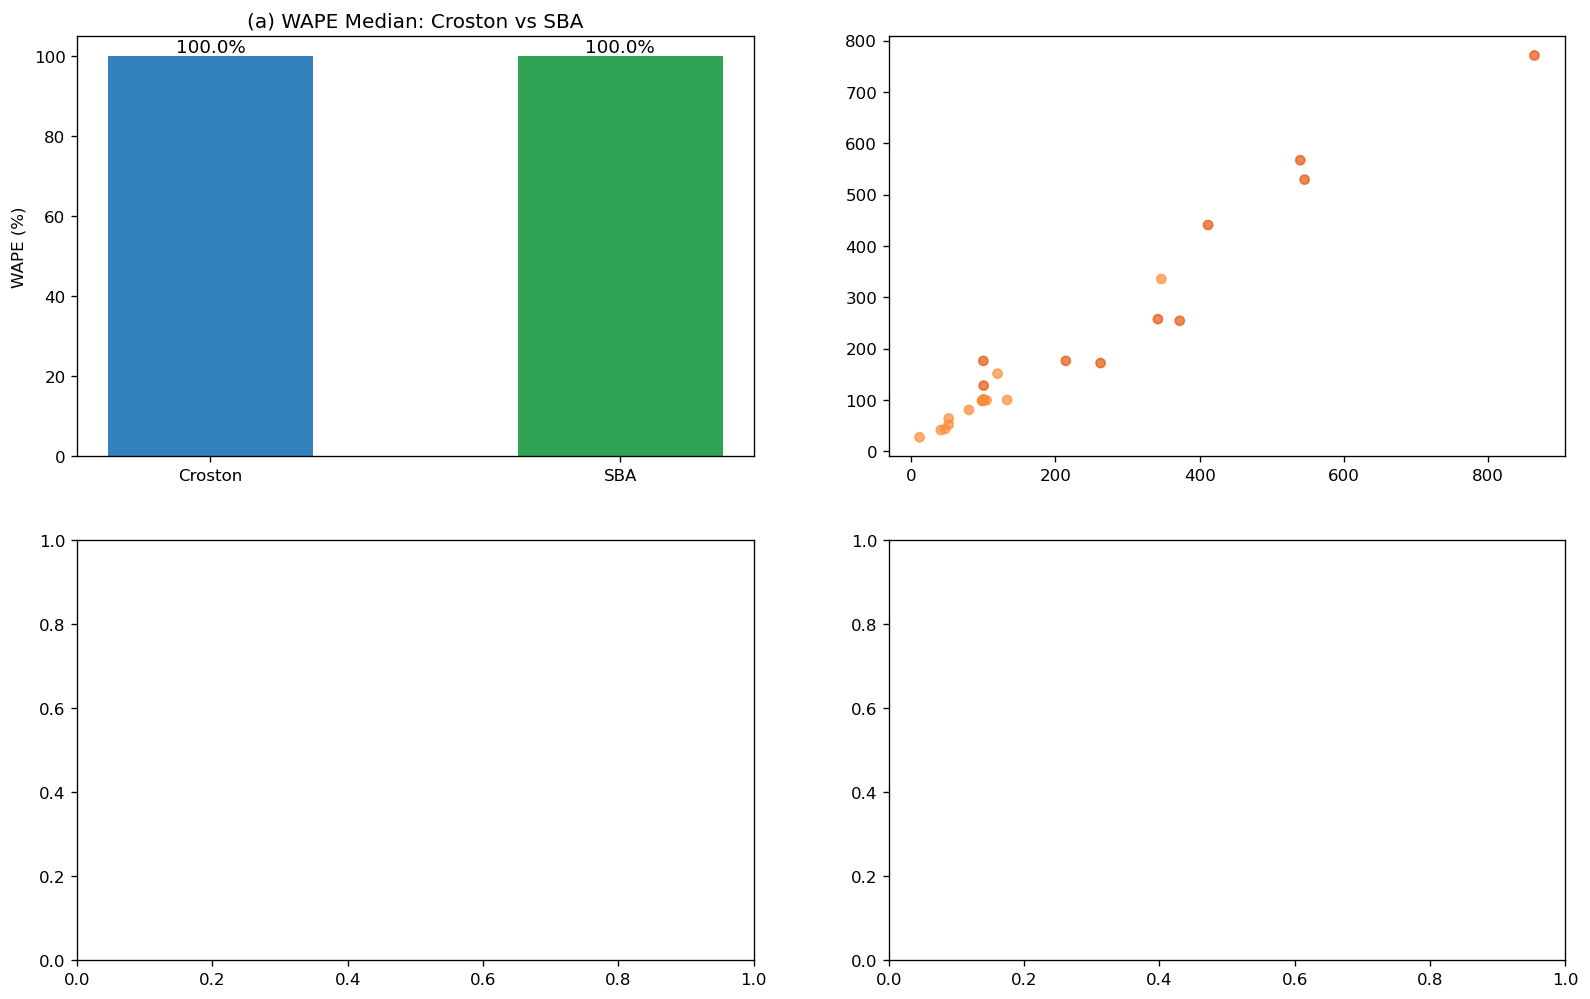

In [43]:
# Perbandingan Croston vs SBA per obat
cmp=pd.DataFrame({'WAPE_Croston':cro['WAPE'],'WAPE_SBA':sba['WAPE']}).dropna()
cmp['Lebih_baik']=np.where(cmp.WAPE_SBA<cmp.WAPE_Croston,'SBA','Croston')
cmp['delta_WAPE']=(cmp.WAPE_SBA-cmp.WAPE_Croston).round(1)
cmp['kategori']=kat.reindex(cmp.index)

print(f'SBA lebih baik: {int((cmp.WAPE_SBA<cmp.WAPE_Croston).sum())} dari {len(cmp)} obat')

fig,axes=plt.subplots(2,2,figsize=(16,10))

# (a) Bar median
med=cmp[['WAPE_Croston','WAPE_SBA']].median()
axes[0,0].bar(['Croston','SBA'],med.values,color=['#3182bd','#31a354'],width=0.5)
for i,v in enumerate(med.values): axes[0,0].text(i,v+1,f'{v:.1f}%',ha='center',fontsize=11)
axes[0,0].set_title('(a) WAPE Median: Croston vs SBA'); axes[0,0].set_ylabel('WAPE (%)')

# (b) Scatter per obat
colors_c=cmp['kategori'].map({'intermittent':'#fd8d3c','lumpy':'#e6550d'}).fillna('gray')
axes[0,1].scatter(cmp.WAPE_Croston,cmp.WAPE_SBA,s=30,alpha=0.7,c=colors_c)
mx=max(cmp.max().max(),10)+10
axes[0,1].plot([0,mx],[0,mx],'k--',lw=0.8,label='Sama')
axes[0,1].set_xlabel('WAPE Croston'); axes[0,1].set_ylabel('WAPE SBA')
axes[0,1].set_title('(b) Croston vs SBA per Obat\n(di bawah garis = SBA lebih baik)')
from matplotlib.patches import Patch
axes[0,1].legend(handles=[Patch(fc='#fd8d3c',label='intermittent'),
                           Patch(fc='#e6550d',label='lumpy'),
                           mpatches.Patch(fc='none',ec='k',ls='--',label='Sama')],fontsize=8)

# (c) Histogram delta WAPE
axes[1,0].hist(cmp.delta_WAPE,bins=25,color='#9ecae1',edgecolor='white')
axes[1,0].axvline(0,color='black',lw=1.2,ls='--')
axes[1,0].axvline(cmp.delta_WAPE.median(),color='red',lw=1.5,
                  label=f'Median={cmp.delta_WAPE.median():.1f}')
axes[1,0].set_title('(c) Delta WAPE (SBA - Croston)\n< 0 = SBA lebih baik')
axes[1,0].set_xlabel('Delta WAPE'); axes[1,0].legend()

# (d) Aktual vs ramalan 6 obat intermittent/lumpy terbaik (SBA)
best6_int=sba['WAPE'].dropna().nsmallest(6).index.tolist()
ax_big=axes[1,1]; ax_big.set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'croston_vs_sba.png'),dpi=150,bbox_inches='tight')
plt.show()

print('\n--- Perbandingan Croston vs SBA per obat ---')
display(cmp.sort_values('delta_WAPE')
        .style.background_gradient(subset=['WAPE_Croston','WAPE_SBA'],cmap='RdYlGn_r')
        .bar(subset=['delta_WAPE'],align='zero',color=['#d65f5f','#5fba7d'])
        .format({'WAPE_Croston':'{:.1f}','WAPE_SBA':'{:.1f}','delta_WAPE':'{:+.1f}'}))

In [ ]:
# Visualisasi aktual vs ramalan Croston/SBA per obat terbaik (3 each)
best3_cro=cro['WAPE'].dropna().nsmallest(3).index.tolist()
best3_sba=sba['WAPE'].dropna().nsmallest(3).index.tolist()
fig,axes=plt.subplots(2,3,figsize=(18,8))
for row,obat_list,method,src,col in [
    (0,best3_cro,'Croston',cro,'#3182bd'),
    (1,best3_sba,'SBA',sba,'#31a354')]:
    for col_i,ob in enumerate(obat_list):
        ax=axes[row,col_i]
        s=[0.0 if np.isnan(v) else v for v in X_clean.loc[ob].values]
        az,ap=float(src.loc[ob,'alpha_z']),float(src.loc[ob,'alpha_p'])
        fn=croston_next if method=='Croston' else sba_next
        fc_v=[np.nan]
        for i in range(1,12):
            tr=[x for x in s[:i] if not np.isnan(x)]
            fc_v.append(fn(tr,az,ap) if len(tr)>=2 else np.nan)
        aktual=s
        ax.fill_between(range(1,13),[0]*12,aktual,alpha=0.1,color='black')
        ax.plot(range(1,13),aktual,'o-',color='black',lw=1.5,ms=4,label='Aktual')
        ax.plot(range(1,12),fc_v[1:],'s--',color=col,lw=1.5,ms=4,
                label=f'{method} az={az},ap={ap}')
        ax.axvspan(10.5,12.5,alpha=0.12,color='gold')
        w=src.loc[ob,'WAPE']
        ax.set_title(f'{method} TOP #{col_i+1}\n{ob[:28]}\nWAPE={w:.1f}%',fontsize=8)
        ax.set_xticks(range(1,13))
        ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'],fontsize=6)
        if col_i==0: ax.legend(fontsize=7)
plt.suptitle('Aktual vs Ramalan — Croston (atas) & SBA (bawah) TOP 3',fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'croston_sba_aktual_vs_ramalan.png'),dpi=150,bbox_inches='tight')
plt.show()

## 10. Pemilihan Metode Terbaik per Obat

| Kategori | Kandidat | Aturan |
|---|---|---|
| smooth, erratic | SES | Satu kandidat |
| intermittent, lumpy | Croston vs SBA | Pilih WAPE test lebih rendah |
| data tidak cukup | — | Strategi mean (AMC) |

In [ ]:
rows=[]
for ob in X_clean.index:
    c=kat[ob]
    if c in ('smooth','erratic'):
        a=float(ses_df.loc[ob,'alpha']) if ob in ses_df.index else 0.3
        wv=ses_df.loc[ob,'WAPE'] if ob in ses_df.index else np.nan
        rows.append([ob,c,'SES',wv,f'alpha={a:.2f}'])
    elif c in ('intermittent','lumpy'):
        wc=cro.loc[ob,'WAPE'] if ob in cro.index else np.nan
        ws=sba.loc[ob,'WAPE'] if ob in sba.index else np.nan
        if np.isnan(wc) and np.isnan(ws):
            rows.append([ob,c,'-',np.nan,'-']); continue
        if np.isnan(ws) or (not np.isnan(wc) and wc<=ws):
            p=f'az={cro.loc[ob,"alpha_z"]:.2f},ap={cro.loc[ob,"alpha_p"]:.2f}' if ob in cro.index else ''
            rows.append([ob,c,'Croston',wc,p])
        else:
            p=f'az={sba.loc[ob,"alpha_z"]:.2f},ap={sba.loc[ob,"alpha_p"]:.2f}' if ob in sba.index else ''
            rows.append([ob,c,'SBA',ws,p])
    else:
        rows.append([ob,c,'aturan stok',np.nan,'-'])

final=pd.DataFrame(rows,columns=['obat','kategori_demand','metode_terbaik','WAPE_test','parameter']).set_index('obat')

print('--- Distribusi metode terbaik ---')
print(final.metode_terbaik.value_counts().to_string())
print()
print('--- WAPE median per kategori ---')
print(final.dropna(subset=['WAPE_test']).groupby('kategori_demand')['WAPE_test'].median().round(1).to_string())

print('\n--- Tabel lengkap metode terbaik per obat ---')
display(final.sort_values(['kategori_demand','WAPE_test'])
        .style.background_gradient(subset=['WAPE_test'],cmap='RdYlGn_r')
        .format({'WAPE_test':'{:.1f}'}))

## 11. E2 — Volume Kunjungan sebagai External Predictor

November 2025: hanya **102 kunjungan** vs rata-rata train **503** → forecast harus turun.

$$F^{E2}_t = F_t \times \frac{\text{kunjungan}(t)}{\overline{\text{kunjungan}}_{\text{train}}}$$

In [ ]:
visit_raw=raw.groupby('bulan')['Register'].nunique()
visit_train_mean=float(visit_raw[visit_raw.index<=10].mean())
visit_scale={int(m):float(v/visit_train_mean) for m,v in visit_raw.items()}

# Tabel visit scale
tbl_vs=pd.DataFrame({'kunjungan_unik':visit_raw,
                     'visit_scale':[visit_scale.get(m,1.0) for m in range(1,13)],
                     'bulan_nama':['Jan','Feb','Mar','Apr','Mei','Jun',
                                   'Jul','Agu','Sep','Okt','Nov','Des']},
                    index=range(1,13))
tbl_vs['vs_train_mean']=[visit_train_mean]*12
print(f'Visit train mean (bln 1-10): {visit_train_mean:.1f}')
print()
display(tbl_vs.style
        .background_gradient(subset=['kunjungan_unik'],cmap='Blues')
        .background_gradient(subset=['visit_scale'],cmap='RdYlGn')
        .format({'kunjungan_unik':'{:.0f}','visit_scale':'{:.4f}','vs_train_mean':'{:.1f}'}))

In [ ]:
# Hitung dampak E2
rows_e2=[]
for ob in X_clean.index:
    c=kat[ob]; met=final.loc[ob,'metode_terbaik'] if ob in final.index else '-'
    if met not in ('SES','Croston','SBA'): continue
    if met=='SES':
        a=float(ses_df.loc[ob,'alpha']) if ob in ses_df.index else 0.3
        s=make_series(X_winsor,ob); fc=lambda tr,a=a:ses_next(tr,a); src_s=s
    else:
        src=cro if met=='Croston' else sba
        az,ap=float(src.loc[ob,'alpha_z']),float(src.loc[ob,'alpha_p'])
        fn=croston_next if met=='Croston' else sba_next
        fc=lambda tr,az=az,ap=ap:fn(tr,az,ap)
        src_s=[0.0 if np.isnan(v) else v for v in X_clean.loc[ob].values]
    at,ft=wf(src_s,fc,TEST_M); wb=WAPE(at,ft)
    a2,f2=[],[]
    for tm in TEST_M:
        idx=tm-1; tr=[x for x in src_s[:idx] if not np.isnan(x)]
        if len(tr)<2 or pd.isna(src_s[idx]): continue
        a2.append(src_s[idx]); f2.append(max(fc(tr)*visit_scale.get(tm,1.0),0))
    we=WAPE(np.array(a2),np.array(f2)) if a2 else np.nan
    rows_e2.append({'obat':ob,'kategori':c,'metode':met,'WAPE_base':wb,'WAPE_E2':we,
                    'delta':round(we-wb,1) if pd.notna(wb) and pd.notna(we) else np.nan})

df_e2=pd.DataFrame(rows_e2).set_index('obat')
overall_base=df_e2['WAPE_base'].median(); overall_e2=df_e2['WAPE_E2'].median()
print(f'WAPE Tanpa E2 : {overall_base:.1f}%')
print(f'WAPE Dengan E2: {overall_e2:.1f}%  (delta={overall_e2-overall_base:+.1f}%)')

print('\n--- Dampak E2 per kategori ---')
display(df_e2.groupby('kategori')[['WAPE_base','WAPE_E2','delta']].median().round(1)
        .style.background_gradient(cmap='RdYlGn_r',subset=['WAPE_base','WAPE_E2'])
        .bar(subset=['delta'],align='zero',color=['#d65f5f','#5fba7d']))

print('\n--- Dampak E2 per obat (semua, diurutkan delta terkecil = paling dibantu E2) ---')
display(df_e2.sort_values('delta')
        .style.background_gradient(subset=['WAPE_base','WAPE_E2'],cmap='RdYlGn_r')
        .bar(subset=['delta'],align='zero',color=['#d65f5f','#5fba7d'])
        .format({'WAPE_base':'{:.1f}','WAPE_E2':'{:.1f}','delta':'{:+.1f}'}))

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
cat_order=['smooth','erratic','intermittent','lumpy']
mb=df_e2.groupby('kategori')['WAPE_base'].median().reindex(cat_order)
me=df_e2.groupby('kategori')['WAPE_E2'].median().reindex(cat_order)
x=np.arange(len(cat_order)); w=0.35
axes[0].bar(x-w/2,mb,w,label='Tanpa E2',color='#3182bd',alpha=0.85)
axes[0].bar(x+w/2,me,w,label='Dengan E2',color='#31a354',alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(cat_order,rotation=10)
axes[0].set_ylabel('WAPE median (%)'); axes[0].set_title('(a) WAPE Base vs E2 per Kategori')
axes[0].legend()

delta=df_e2['delta'].dropna()
axes[1].hist(delta,bins=30,color='#9ecae1',edgecolor='white')
axes[1].axvline(0,color='black',lw=1.2,ls='--')
axes[1].axvline(delta.median(),color='red',lw=1.5,label=f'Median={delta.median():.1f}')
axes[1].set_xlabel('Delta WAPE (E2 - Base)'); axes[1].set_ylabel('Jumlah obat')
axes[1].set_title('(b) Distribusi delta WAPE\n(negatif = E2 membantu)'); axes[1].legend()

months=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
scales=[visit_scale.get(m,1.0) for m in range(1,13)]
clrs_vs=['#e74c3c' if s<0.5 else('#f39c12' if s<0.8 else '#27ae60') for s in scales]
bars=axes[2].bar(months,scales,color=clrs_vs,edgecolor='white')
axes[2].axhline(1.0,color='gray',ls='--',lw=1,label='Scale=1')
for bar,sc in zip(bars,scales):
    axes[2].text(bar.get_x()+bar.get_width()/2,sc+0.02,f'{sc:.2f}',ha='center',fontsize=8)
axes[2].set_title('(c) Visit Scale per Bulan'); axes[2].set_ylabel('Scale')
axes[2].tick_params(axis='x',rotation=40); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'e2_visit_scale.png'),dpi=150,bbox_inches='tight')
plt.show()

## 12. Evaluasi Komprehensif (dengan E2)

| Mutu | WAPE | Keterangan |
|---|---|---|
| Excellent | ≤20% | Sangat akurat |
| Good | ≤50% | Dapat diterima |
| Bad | ≤100% | Perlu waspada |
| Tidak Layak | >100% | Overestimate/Underestimate besar |

In [ ]:
def _test_pairs_e2(ob):
    met=final.loc[ob,'metode_terbaik'] if ob in final.index else '-'
    if met=='SES':
        a=float(ses_df.loc[ob,'alpha']) if ob in ses_df.index else 0.3
        s=make_series(X_winsor,ob); fc=lambda tr,a=a:ses_next(tr,a)
    elif met in ('Croston','SBA'):
        src=cro if met=='Croston' else sba
        az,ap=float(src.loc[ob,'alpha_z']),float(src.loc[ob,'alpha_p'])
        fn=croston_next if met=='Croston' else sba_next
        fc=lambda tr,az=az,ap=ap:fn(tr,az,ap)
        s=[0.0 if np.isnan(v) else v for v in X_clean.loc[ob].values]
    else: return np.array([]),np.array([])
    a_,f_=[],[]
    for tm in TEST_M:
        idx=tm-1; tr=[x for x in s[:idx] if not np.isnan(x)]
        if len(tr)<2 or pd.isna(s[idx]): continue
        f_.append(max(fc(tr)*visit_scale.get(tm,1.0),0)); a_.append(s[idx])
    return np.array(a_),np.array(f_)

eval_rows=[]
for ob in final.index:
    a,f=_test_pairs_e2(ob)
    eval_rows.append({'obat':ob,
                      'kategori':final.loc[ob,'kategori_demand'],
                      'metode':final.loc[ob,'metode_terbaik'],
                      'WAPE':round(WAPE(a,f),1),'MAPE':round(MAPE(a,f),1),
                      'MAD':round(MAD(a,f),2),'MSE':round(MSE(a,f),2),
                      'mutu':mutu(WAPE(a,f))})

eval_df=pd.DataFrame(eval_rows).set_index('obat')

print('=== Distribusi Mutu ===')
print(eval_df['mutu'].value_counts().to_string())
print()
print('=== Metrik Keseluruhan (median) ===')
ne=eval_df[eval_df.mutu.notna()&(eval_df.mutu!='N/A')]
for m in ['WAPE','MAPE','MAD','MSE']: print(f'  {m}: {ne[m].median():.2f}')

# Ringkasan per kategori
print('\n--- Metrik per kategori (median) ---')
display(eval_df.groupby('kategori')[['WAPE','MAPE','MAD','MSE']].median().round(2)
        .style.background_gradient(cmap='RdYlGn_r',subset=['WAPE','MAPE']))

print('\n--- Tabel evaluasi per obat (semua, diurutkan WAPE) ---')
display(eval_df.sort_values('WAPE')
        .style.background_gradient(subset=['WAPE'],cmap='RdYlGn_r')
        .background_gradient(subset=['MAD','MSE'],cmap='Oranges')
        .format({'WAPE':'{:.1f}','MAPE':'{:.1f}','MAD':'{:.2f}','MSE':'{:.1f}'}))

In [ ]:
fig,axes=plt.subplots(2,3,figsize=(18,10))

# (a) Pie mutu
mutu_cnt=eval_df['mutu'].value_counts()
clrs_m={'Excellent':'#27ae60','Good':'#f1c40f','Bad':'#e67e22','Tidak Layak':'#e74c3c','N/A':'#bdc3c7'}
axes[0,0].pie(mutu_cnt,labels=[f'{k}\n({v})' for k,v in mutu_cnt.items()],
              colors=[clrs_m.get(k,'gray') for k in mutu_cnt.index],
              autopct='%1.0f%%',startangle=90,wedgeprops=dict(edgecolor='white',lw=1.5))
axes[0,0].set_title('(a) Distribusi Mutu Forecast')

# (b) Boxplot WAPE per kategori
valid=eval_df[eval_df.WAPE.notna()&(eval_df.WAPE<500)]
cat_sorted=valid.groupby('kategori')['WAPE'].median().sort_values().index
sns.boxplot(data=valid,x='kategori',y='WAPE',order=cat_sorted,palette='Set2',ax=axes[0,1])
axes[0,1].axhline(50,color='green',ls='--',lw=1,label='Good (50%)')
axes[0,1].axhline(100,color='red',ls='--',lw=1,label='Bad (100%)')
axes[0,1].set_title('(b) Boxplot WAPE per Kategori'); axes[0,1].legend(fontsize=8)

# (c) WAPE ranked (semua obat)
ranked=valid.sort_values('WAPE')
colors_r=[clrs_m.get(mutu(w),'gray') for w in ranked.WAPE]
axes[0,2].bar(range(len(ranked)),ranked.WAPE,color=colors_r,width=1.0)
axes[0,2].axhline(50,color='green',ls='--',lw=1)
axes[0,2].axhline(100,color='red',ls='--',lw=1)
axes[0,2].set_xlabel('Obat (rank)'); axes[0,2].set_ylabel('WAPE (%)')
axes[0,2].set_title('(c) WAPE Semua Obat (ranked)')
axes[0,2].legend(handles=[mpatches.Patch(fc=v,label=k) for k,v in clrs_m.items() if k!='N/A'],fontsize=7)

# (d) WAPE Base vs E2 per metode
for met,col in [('SES','#3182bd'),('Croston','#fd8d3c'),('SBA','#31a354')]:
    d=df_e2[df_e2.metode==met]
    if len(d)==0: continue
    wb=d['WAPE_base'].median(); we=d['WAPE_E2'].median()
    axes[1,0].barh([met+' Base',met+' E2'],[wb,we],color=[col,col],alpha=[0.5,1.0])
axes[1,0].set_xlabel('WAPE median (%)'); axes[1,0].set_title('(d) WAPE per Metode: Base vs E2')

# (e) Scatter MAD vs WAPE
axes[1,1].scatter(valid['WAPE'],valid['MAD'],s=20,alpha=0.6,
                  c=valid['kategori'].map({'smooth':'#3182bd','erratic':'#6baed6',
                                          'intermittent':'#fd8d3c','lumpy':'#e6550d'}).fillna('gray'))
axes[1,1].set_xlabel('WAPE (%)'); axes[1,1].set_ylabel('MAD (unit)')
axes[1,1].set_title('(e) WAPE vs MAD per Obat')

# (f) MAPE vs WAPE per kategori
for cat,marker,color in [('smooth','o','#3182bd'),('erratic','s','#6baed6'),
                          ('intermittent','^','#fd8d3c'),('lumpy','D','#e6550d')]:
    d=valid[valid.kategori==cat]
    if len(d): axes[1,2].scatter(d['WAPE'],d['MAPE'],s=20,marker=marker,
                                  color=color,label=cat,alpha=0.7)
axes[1,2].plot([0,500],[0,500],'k--',lw=0.8,label='WAPE=MAPE')
axes[1,2].set_xlabel('WAPE (%)'); axes[1,2].set_ylabel('MAPE (%)')
axes[1,2].set_title('(f) WAPE vs MAPE (titik di atas=MAPE lebih tinggi)')
axes[1,2].legend(fontsize=7); axes[1,2].set_xlim(0,500); axes[1,2].set_ylim(0,500)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'evaluasi_komprehensif.png'),dpi=150,bbox_inches='tight')
plt.show()

## 13. Analisis Musiman & Trend

In [ ]:
prows=[]
for ob in X.index:
    v=X.loc[ob].dropna()
    if len(v)<3 or v.std(ddof=0)==0: continue
    z=(v-v.mean())/v.std(ddof=0)
    for m,val in z.items(): prows.append((m,val))
pnl=pd.DataFrame(prows,columns=['bulan','z'])
F,pval=stats.f_oneway(*[g['z'].values for _,g in pnl.groupby('bulan')])
print(f'ANOVA efek bulan: F={F:.2f}, p={pval:.2e}')
print(f'-> {"SIGNIFIKAN" if pval<0.05 else "Tidak signifikan"}')

rr=[]
for ob in X.index:
    v=X.loc[ob].dropna()
    if len(v)<3 or v.mean()==0: continue
    for m,val in (v/v.mean()).items(): rr.append((m,val))
seas=pd.DataFrame(rr,columns=['bulan','r']).groupby('bulan')['r'].agg(['mean','sem','count']).reindex(range(1,13))

print('\n--- Indeks Musiman per Bulan ---')
seas_disp=seas.copy(); seas_disp.index=(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
seas_disp['visit_scale']=[visit_scale.get(m,1.0) for m in range(1,13)]
display(seas_disp.round(3).style.background_gradient(subset=['mean'],cmap='RdYlGn')
        .background_gradient(subset=['visit_scale'],cmap='Blues'))

fig,axes=plt.subplots(1,2,figsize=(16,5))
axes[0].bar(range(1,13),seas['mean'],yerr=seas['sem'],color='#9ecae1',
            error_kw={'ecolor':'gray','capsize':3},label='Indeks Musiman (pool)')
ax2t=axes[0].twinx()
ax2t.plot(range(1,13),[visit_scale.get(m,1.0) for m in range(1,13)],
          'o-',color='#e6550d',ms=6,label='Visit Scale (E2)')
axes[0].axhline(1.0,color='gray',ls='--',lw=0.8)
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[0].set_ylabel('Indeks Musiman'); ax2t.set_ylabel('Visit Scale',color='#e6550d')
axes[0].set_title('Indeks Musiman vs Visit Scale (E2)')
axes[0].legend(loc='upper left',fontsize=8); ax2t.legend(loc='upper right',fontsize=8)

# Korelasi indeks musiman vs visit scale
r_s,p_s=stats.pearsonr(seas['mean'].fillna(0),[visit_scale.get(m,1.0) for m in range(1,13)])
axes[1].scatter(seas['mean'].fillna(0),[visit_scale.get(m,1.0) for m in range(1,13)],s=80,
                c=range(1,13),cmap='RdYlGn')
for m in range(1,13):
    axes[1].annotate(['J','F','M','A','M','J','J','A','S','O','N','D'][m-1],
                     (seas['mean'].iloc[m-1],visit_scale.get(m,1.0)),
                     textcoords='offset points',xytext=(5,5),fontsize=8)
axes[1].set_xlabel('Indeks Musiman Demand (pool)')
axes[1].set_ylabel('Visit Scale (E2)')
axes[1].set_title(f'Korelasi Indeks Musiman vs Visit Scale\nr={r_s:.3f}, p={p_s:.3f}')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'seasonal_vs_visit.png'),dpi=150,bbox_inches='tight')
plt.show()

## 14. Kebijakan Stok Min-Max + Safety Stock

$$SS = Z\cdot\sigma\cdot\sqrt{LT} \qquad \text{Min(ROP)} = AMC\cdot LT + SS \qquad \text{Max} = AMC\cdot(LT+R) + Z\cdot\sigma\cdot\sqrt{LT+R}$$

**LT=1 bln, R=1 bln, Z=1.65 (SL 95%)**

In [ ]:
AMC_ser=X_clean.apply(lambda s: s.dropna().mean() if s.dropna().size else 0.0,axis=1)
SIG_ser=X_clean.apply(lambda s: s.dropna().std(ddof=0) if s.dropna().size>1 else 0.0,axis=1)
TOT_ser=X_clean.apply(lambda s: s.dropna().sum(),axis=1)

inv=pd.DataFrame({'AMC':AMC_ser.round(1),'sigma':SIG_ser.round(1),'total_thn':TOT_ser.round(0)})
inv['safety_stock']=(Z*SIG_ser*math.sqrt(LT)).apply(lambda x: int(math.ceil(x)))
inv['Min']=(AMC_ser*LT+Z*SIG_ser*math.sqrt(LT)).apply(lambda x: int(math.ceil(x)))
inv['Max']=(AMC_ser*(LT+R)+Z*SIG_ser*math.sqrt(LT+R)).apply(lambda x: int(math.ceil(x)))

# ABC Pareto
ab=inv.sort_values('total_thn',ascending=False)
kum=ab['total_thn'].cumsum()/ab['total_thn'].sum()*100
inv['ABC']=kum.map(lambda c: 'A' if c<=80 else('B' if c<=95 else 'C'))

# VEN dari ICD-10
VEN_BAB={**dict.fromkeys(list('ABCDIOPS T'),'V'),
         **dict.fromkeys(list('EFGHJKMNQ'),'E'),
         **dict.fromkeys(list('LRZ'),'N')}
kd=raw.dropna(subset=['Resep Obat','Kode Diagnosa']).copy()
kd['Kode Diagnosa']=kd['Kode Diagnosa'].astype(str).str.strip()
dom=kd.groupby('Resep Obat')['Kode Diagnosa'].agg(lambda s: s.value_counts().index[0])
inv['VEN']=dom.reindex(inv.index).str[0].map(VEN_BAB).fillna('N')

# Stok terkini
ks=raw.dropna(subset=['Resep Obat','SISA_STOK']).sort_values('bulan')
inv['stok_terkini']=ks.groupby('Resep Obat')['SISA_STOK'].last().reindex(inv.index)
inv['status']=np.where(inv.stok_terkini.isna(),'tidak diketahui',
               np.where(inv.stok_terkini<=inv.Min,'DI BAWAH MIN','aman'))
inv['perlu_pesan']=inv.apply(
    lambda r: int(max(0,r.Max-r.stok_terkini)) if pd.notna(r.stok_terkini) and r.stok_terkini<=r.Min else 0,axis=1)

print('ABC:', inv.ABC.value_counts().to_dict())
print('VEN:', inv.VEN.value_counts().to_dict())
print('Status:', inv.status.value_counts().to_dict())
print(f'Obat perlu dipesan: {int((inv.perlu_pesan>0).sum())}')

print('\n--- Tabel kebijakan stok per obat (semua obat, diurutkan ABC lalu total) ---')
display(inv.sort_values(['ABC','total_thn'],ascending=[True,False])
        .style.apply(lambda r: ['background-color:#ffe6e6' if v=='DI BAWAH MIN' else '' for v in r],
                     subset=['status'],axis=0)
        .background_gradient(subset=['AMC','sigma','total_thn'],cmap='Blues')
        .background_gradient(subset=['safety_stock','Min','Max'],cmap='Oranges')
        .format({'AMC':'{:.1f}','sigma':'{:.1f}','total_thn':'{:.0f}',
                 'safety_stock':'{:.0f}','Min':'{:.0f}','Max':'{:.0f}',
                 'stok_terkini':'{:.0f}','perlu_pesan':'{:.0f}'}))

In [ ]:
fig,axes=plt.subplots(2,3,figsize=(18,10))

# (a) Pareto ABC
ab2=inv.sort_values('total_thn',ascending=False).reset_index()
axes[0,0].bar(range(len(ab2)),ab2['total_thn'],color='#9ecae1',width=1.0)
ax_p=axes[0,0].twinx()
kum2=ab2['total_thn'].cumsum()/ab2['total_thn'].sum()*100
ax_p.plot(range(len(ab2)),kum2,color='#e6550d',lw=2)
ax_p.axhline(80,color='green',ls='--',lw=1,label='80% (A)')
ax_p.axhline(95,color='orange',ls='--',lw=1,label='95% (B)')
axes[0,0].set_title('(a) Kurva Pareto ABC'); axes[0,0].set_xlabel('Obat (rank)')
axes[0,0].set_ylabel('Total/thn'); ax_p.set_ylabel('Kumulatif %')
ax_p.legend(fontsize=8)

# (b) Matriks ABC x VEN
ct=pd.crosstab(inv['ABC'],inv['VEN']).reindex(index=['A','B','C'],columns=['V','E','N']).fillna(0)
im=axes[0,1].imshow(ct.values,cmap='YlOrRd')
axes[0,1].set_xticks([0,1,2]); axes[0,1].set_xticklabels(['V','E','N'])
axes[0,1].set_yticks([0,1,2]); axes[0,1].set_yticklabels(['A','B','C'])
for i in range(3):
    for j in range(3): axes[0,1].text(j,i,int(ct.values[i,j]),ha='center',va='center',fontsize=14,fontweight='bold')
plt.colorbar(im,ax=axes[0,1],shrink=0.8); axes[0,1].set_title('(b) Matriks ABC x VEN')

# (c) Status stok pie
sc=inv['status'].value_counts()
clrs_st={'aman':'#27ae60','DI BAWAH MIN':'#e74c3c','tidak diketahui':'#bdc3c7'}
axes[0,2].pie(sc,labels=[f'{k}\n({v})' for k,v in sc.items()],
              colors=[clrs_st.get(k,'gray') for k in sc.index],
              autopct='%1.0f%%',startangle=90,wedgeprops=dict(edgecolor='white',lw=1.5))
axes[0,2].set_title('(c) Status Stok Terkini')

# (d) Min vs stok_terkini (obat yang ada stok)
inv_k=inv.dropna(subset=['stok_terkini']).sort_values('Min',ascending=False).head(30)
x_pos=np.arange(len(inv_k))
axes[1,0].bar(x_pos,inv_k['Max'],color='#d5e8d4',label='Max',width=0.5)
axes[1,0].bar(x_pos,inv_k['Min'],color='#dae8fc',label='Min',width=0.5)
axes[1,0].scatter(x_pos,inv_k['stok_terkini'],
                  c=inv_k['status'].map({'aman':'green','DI BAWAH MIN':'red','tidak diketahui':'gray'}),
                  zorder=5,s=40,label='Stok Terkini')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels([o[:15] for o in inv_k.index],rotation=80,fontsize=6)
axes[1,0].set_ylabel('Unit'); axes[1,0].set_title('(d) Min/Max vs Stok Terkini (Top 30 by Min)')
axes[1,0].legend(fontsize=8)

# (e) Distribusi AMC per ABC
for abc,color in [('A','#e74c3c'),('B','#f39c12'),('C','#27ae60')]:
    d=inv[inv.ABC==abc]['AMC']
    if len(d): axes[1,1].hist(d,bins=20,alpha=0.6,color=color,label=f'{abc} ({len(d)})',edgecolor='white')
axes[1,1].set_title('(e) Distribusi AMC per Kelas ABC')
axes[1,1].set_xlabel('AMC (unit/bln)'); axes[1,1].legend()

# (f) Safety stock distribution
axes[1,2].hist(inv['safety_stock'],bins=25,color='#9b59b6',edgecolor='white')
axes[1,2].axvline(inv['safety_stock'].median(),color='red',ls='--',
                  label=f'Median={inv["safety_stock"].median():.0f}')
axes[1,2].set_title('(f) Distribusi Safety Stock (unit)')
axes[1,2].set_xlabel('Safety Stock'); axes[1,2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'kebijakan_stok.png'),dpi=150,bbox_inches='tight')
plt.show()

## 15. Tabel Master Rekomendasi Restok

In [ ]:
master=final.join(inv[['ABC','VEN','AMC','safety_stock','Min','Max','stok_terkini','status','perlu_pesan']])
master['WAPE_E2']=eval_df['WAPE'].reindex(master.index)
master['mutu']=eval_df['mutu'].reindex(master.index)
wA={'A':3,'B':2,'C':1}; wV={'V':3,'E':2,'N':1}
master['skor_prioritas']=master['ABC'].map(wA).fillna(1)+master['VEN'].map(wV).fillna(1)
master['kritis']=master['status'].astype(str).str.contains('BAWAH')
master=master.sort_values(['kritis','skor_prioritas','perlu_pesan'],ascending=[False,False,False])

print(f'Total obat kritis (stok < Min): {int(master.kritis.sum())}')
print(f'Total unit perlu dipesan      : {int(master.perlu_pesan.fillna(0).sum())}')

print('\n--- Tabel MASTER LENGKAP (diurutkan prioritas) ---')
def highlight_status(row):
    if row['kritis']: return ['background-color:#ffe6e6']*len(row)
    return ['']*len(row)

display(master[['kategori_demand','ABC','VEN','metode_terbaik','WAPE_E2','mutu',
                 'AMC','safety_stock','Min','Max','stok_terkini','perlu_pesan','skor_prioritas']]
        .style.apply(highlight_status,axis=1)
        .background_gradient(subset=['WAPE_E2'],cmap='RdYlGn_r')
        .background_gradient(subset=['skor_prioritas'],cmap='Oranges')
        .background_gradient(subset=['perlu_pesan'],cmap='Reds')
        .format({'WAPE_E2':'{:.1f}','AMC':'{:.1f}','safety_stock':'{:.0f}',
                 'Min':'{:.0f}','Max':'{:.0f}','stok_terkini':'{:.0f}','perlu_pesan':'{:.0f}',
                 'skor_prioritas':'{:.0f}'})
        .set_caption('Merah = stok kritis (di bawah Min) | Diurutkan prioritas tertinggi'))

# Ringkasan per ABC-VEN
print('\n--- Ringkasan per kelas ABC-VEN ---')
display(master.groupby(['ABC','VEN']).agg(
    n_obat=('metode_terbaik','count'),
    n_kritis=('kritis','sum'),
    total_pesan=('perlu_pesan','sum'),
    WAPE_median=('WAPE_E2','median'),
    AMC_median=('AMC','median')
).round(1).style.background_gradient(cmap='Reds',subset=['n_kritis'])
              .background_gradient(cmap='Oranges',subset=['total_pesan']))

## 16. Model Artifact — RestockModelV2

Simpan `RestockModelV2` ke pkl — web app akan load ini saat startup.

In [ ]:
from restock_pipeline_model_v2 import RestockModelV2, compute_visit_scale

per_obat={}
for ob in X_clean.index:
    d={'kategori_demand':kat.get(ob,'data tidak cukup')}
    met=final.loc[ob,'metode_terbaik'] if ob in final.index else 'aturan stok'
    if met=='SES':
        d.update({'method':'SES','alpha':float(ses_df.loc[ob,'alpha']) if ob in ses_df.index else 0.3,'strategy':'method'})
    elif met=='Croston':
        d.update({'method':'Croston','alpha_z':float(cro.loc[ob,'alpha_z']),
                  'alpha_p':float(cro.loc[ob,'alpha_p']),'strategy':'method'})
    elif met=='SBA':
        d.update({'method':'SBA','alpha_z':float(sba.loc[ob,'alpha_z']),
                  'alpha_p':float(sba.loc[ob,'alpha_p']),'strategy':'method'})
    else: d.update({'method':None,'strategy':'mean'})
    d['history_clean'] =[float(v) if not pd.isna(v) else 0.0 for v in X_clean.loc[ob].values]
    d['history_winsor']=[float(v) if not pd.isna(v) else 0.0 for v in X_winsor.loc[ob].values]
    iv=inv.loc[ob] if ob in inv.index else None
    if iv is not None:
        d.update({'ABC':iv.ABC,'VEN':iv.VEN,'AMC':float(iv.AMC or 0),
                  'sigma_bln':float(iv.sigma or 0),
                  'stok_terkini':float(iv.stok_terkini) if pd.notna(iv.stok_terkini) else None,
                  'Min':float(iv.Min or 0),'Max':float(iv.Max or 0),
                  'safety_stock':float(iv.safety_stock or 0),
                  'kebijakan':'Min-Max + Safety Stock (Z=1.65, SL=95%)'})
    per_obat[ob]=d

seasonal_index=compute_visit_scale(raw,date_col='Tanggal Masuk',register_col='Register')

params={'dibuat':pd.Timestamp.now().strftime('%Y-%m-%d'),
        'versi':'FINAL (SES/Croston/SBA + E2 + safety stock Z=1.65)',
        'n_obat':len(per_obat),
        'inventory':{'lead_time_bln':LT,'review_bln':R,'service_level':0.95,'Z':Z},
        'kunjungan_scaler':{'metode':'E2_volume_kunjungan',
                            'visit_train_mean':round(visit_train_mean,2),
                            'keterangan':f'WAPE {overall_base:.1f}%->{overall_e2:.1f}%'}}

model_v2=RestockModelV2(params=params,per_obat=per_obat,seasonal_index=seasonal_index)
with open(PKL_OUT,'wb') as f: pickle.dump(model_v2,f)

print(f'Model disimpan: {PKL_OUT}')
print(f'Jumlah obat   : {len(per_obat)}')
print(f'File size     : {os.path.getsize(PKL_OUT)/1024:.1f} KB')

# Verifikasi: load ulang dan test
with open(PKL_OUT,'rb') as f: m_check=pickle.load(f)
ob_test=list(per_obat.keys())[0]
fc_test=m_check.forecast_next(ob_test,bulan_target=11)
print(f'Verifikasi forecast {ob_test[:30]}: {fc_test:.2f}')
print('\n--- Parameter model ---')
display(pd.DataFrame({'key':list(params.keys()),'value':[str(v)[:80] for v in params.values()]}))

## 17. Kesimpulan & Ringkasan Pipeline

In [ ]:
print('=' * 65)
print('  RINGKASAN HASIL PIPELINE FORECASTING')
print('=' * 65)
print(f'  Total obat           : {len(X_clean)}')
print(f'  Periode data         : Jan-Des 2025')
print()
print('  Distribusi Kategori Demand:')
for k,v in kat.value_counts().items(): print(f'    {k:20s}: {v}')
print()
print('  Distribusi Metode Terbaik:')
for k,v in final.metode_terbaik.value_counts().items(): print(f'    {k:12s}: {v}')
print()
print(f'  WAPE Overall : {overall_base:.1f}% (base) -> {overall_e2:.1f}% (E2)')
print(f'  MAPE Median  : {eval_df["MAPE"].median():.1f}%')
print(f'  MAD Median   : {eval_df["MAD"].median():.2f}')
print()
print('  Distribusi Mutu:')
for k,v in eval_df['mutu'].value_counts().items(): print(f'    {k:14s}: {v}')
print()
print(f'  ABC: {inv.ABC.value_counts().to_dict()}')
print(f'  VEN: {inv.VEN.value_counts().to_dict()}')
print(f'  Stok kritis  : {int(master.kritis.sum())} obat')
print(f'  Total pesan  : {int(master.perlu_pesan.fillna(0).sum())} unit')
print(f'  Model        : {PKL_OUT}')
print('=' * 65)